# About

Explore **`_train` CSVs** (same naming rule as [`heart_age_classifier.py`](heart_age_classifier.py): the filename must contain `_train`) without loading both aorta and brachial files together.

## What you can do

| Area | Purpose |
|------|---------|
| **Class balance** | Bar chart of `target` counts (age decades 20s–70s). |
| **Univariate** | Histogram / KDE for any numeric column; optional overlay per class. |
| **By-class shape** | Violin or box plots of one feature vs. `target`. |
| **Waveforms** | Mean pressure trace vs. sample index (`*_t_*` columns), optionally one curve per class. |
| **Data quality** | Missing-value rates; correlation heatmap on a **sample** of waveform columns so wide tables stay usable. |

## Running this notebook

1. Install dependencies: `pandas`, `numpy`, `matplotlib`, `seaborn`, `ipywidgets`.
2. Optionally set **`SEARCH_ROOT`** in the setup cell (defaults to **`datasets/`** next to the kernel’s working directory).
3. Run all cells in order (setup → plot helpers → dashboard → discover/launch), then use the **CSV** and **Plot** controls.

# Setup
## Imports

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import seaborn as sns

try:
    from scipy.signal import cheby1, sosfiltfilt
except ImportError as e:
    raise ImportError("Install scipy for Chebyshev waveform smoothing: pip install scipy") from e

try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError as e:
    raise ImportError("Install ipywidgets for the UI: pip install ipywidgets") from e


## Dashboard widgets (run these cells top → bottom after the plot helpers above)

1. **Handlers** — `refresh_feature_dropdowns` and `run_dashboard_visualizer(ui)`
2. **`create_dashboard_widgets`** — construct dropdowns/sliders; inspect the returned `dict`
3. **`wire_dashboard_handlers`** — attach observers (run after widgets exist)
4. **`display_dashboard`** / **`build_ui`** — layout, first draw; `build_ui` chains everything for the launch cell below


In [2]:
"""Dropdown refresh and redraw entrypoint for the dashboard."""

def refresh_feature_dropdowns(
    change: dict,
    dd_col,
    dd_prefix,
) -> None:
    """Refresh dropdowns after the selected CSV changes.

    This is intended to be used as an `ipywidgets` observer for the CSV dropdown.
    It reloads the newly selected CSV from disk, then updates:

    - `dd_col` (numeric-feature dropdown options)
    - `dd_prefix` (waveform-family dropdown options), based on detected column-name prefixes

    Notes:
        - The observer `change` payload is expected to include the new filename at `change['new']`.
        - This function uses the notebook-global `SEARCH_ROOT` and other helpers like
          `load_train_csv`, `numeric_columns`, and `waveform_time_indices`.

    Args:
        change: Observer payload from ipywidgets.
        dd_col: Target dropdown widget to update with numeric column names.
        dd_prefix: Target dropdown widget to update with waveform prefixes.
    """
    p = SEARCH_ROOT / change["new"]
    d = load_train_csv(p)
    nums = numeric_columns(d)
    dd_col.options = nums or [""]
    dd_col.value = nums[0] if nums else ""
    pr = list(waveform_time_indices(d.columns).keys())
    dd_prefix.options = pr or [""]
    dd_prefix.value = pr[0] if pr else ""


def run_dashboard_visualizer(ui: dict, _=None) -> None:
    """Draw the selected plot using current widget values.

    This function is the main dashboard entrypoint: it reads the current values
    from widgets stored in the `ui` dict, clears the output area, and then calls
    `run_visualizer(...)` to render a matplotlib figure.

    Expected `ui` keys:
        - `out`: an `ipywidgets.Output` used to capture plot output
        - `dd_file`: dropdown whose `.value` is a relative path under `SEARCH_ROOT`
        - `dd_plot`: dropdown selecting the plot type string
        - `dd_col`: dropdown selecting a numeric column
        - `dd_prefix`: dropdown selecting a waveform prefix
        - `chk_split`, `int_bins`, `chk_kde`, `int_miss`, `int_stride`: plot controls
        - `train_paths_rel`, `int_subject`, `chk_random_subject`: paired waveform plot

    Args:
        ui: Dictionary produced by `create_dashboard_widgets`.
        _: Unused parameter for compatibility with ipywidgets observer/callback signatures.
    """
    out = ui["out"]
    with out:
        out.clear_output(wait=True)
        path = SEARCH_ROOT / ui["dd_file"].value
        run_visualizer(
            str(path),
            ui["dd_plot"].value,
            ui["dd_col"].value,
            ui["dd_prefix"].value,
            ui["chk_split"].value,
            ui["int_bins"].value,
            ui["chk_kde"].value,
            ui["int_miss"].value,
            ui["int_stride"].value,
            ui["train_paths_rel"],
            ui["int_subject"].value,
            ui["chk_random_subject"].value,
        )


In [3]:
def create_dashboard_widgets(paths: list[Path]) -> dict | None:
    """Create and initialize widgets for exploring train CSVs.

    The returned dictionary is later consumed by `wire_dashboard_handlers` and
    `run_dashboard_visualizer`.

    Widget initialization depends on the first file in `paths` (to populate:
    - numeric columns
    - waveform prefixes
    and to provide sensible defaults).

    Args:
        paths: Absolute paths to train CSV files under `SEARCH_ROOT`.

    Returns:
        A dict of widgets (e.g. `dd_file`, `dd_plot`, `dd_col`, `dd_prefix`, control
        widgets, an update `btn`, plus `out`), or `None` when no paths are provided.

    Side effects:
        None; this function only constructs widget objects.
    """
    if not paths:
        return None

    rel = [str(p.relative_to(SEARCH_ROOT)) for p in paths]
    train_paths_rel = rel
    dd_file = widgets.Dropdown(options=rel, description="CSV:", layout=widgets.Layout(width="90%"))
    dd_plot = widgets.Dropdown(
        options=[
            "Target counts",
            "Histogram / KDE",
            "Violin by target",
            "Box by target",
            "Mean waveform",
            "Subject waveforms (aorta + brach)",
            "Subject waveforms by class (stacked)",
            "Missingness",
            "Correlation sample",
        ],
        value="Target counts",
        description="Plot:",
    )
    first_df = load_train_csv(paths[0])
    nums = numeric_columns(first_df)
    dd_col = widgets.Dropdown(options=nums or [""], value=nums[0] if nums else "", description="Column:")
    prefs = list(waveform_time_indices(first_df.columns).keys())
    dd_prefix = widgets.Dropdown(
        options=prefs or [""],
        value=prefs[0] if prefs else "",
        description="Wave prefix:",
    )
    chk_split = widgets.Checkbox(value=True, description="Hist by target")
    int_bins = widgets.IntSlider(value=40, min=10, max=120, step=5, description="Bins")
    chk_kde = widgets.Checkbox(value=True, description="KDE")
    int_miss = widgets.IntSlider(value=30, min=5, max=80, step=5, description="Missing top")
    int_stride = widgets.IntSlider(value=20, min=1, max=50, step=1, description="Corr stride")
    chk_random_subject = widgets.Checkbox(value=False, description="Random subject")
    int_subject = widgets.IntText(value=0, description="subject_index:", style={"description_width": "initial"})

    controls_basic = widgets.VBox([dd_file, dd_plot])
    controls_extra = widgets.VBox(
        [
            dd_col,
            dd_prefix,
            widgets.HBox([chk_random_subject, int_subject]),
            widgets.HBox([chk_split, chk_kde]),
            int_bins,
            int_miss,
            int_stride,
        ]
    )
    btn = widgets.Button(description="Update plot", button_style="primary")
    out = widgets.Output()

    return {
        "dd_file": dd_file,
        "dd_plot": dd_plot,
        "dd_col": dd_col,
        "dd_prefix": dd_prefix,
        "chk_split": chk_split,
        "chk_kde": chk_kde,
        "int_bins": int_bins,
        "int_miss": int_miss,
        "int_stride": int_stride,
        "train_paths_rel": train_paths_rel,
        "int_subject": int_subject,
        "chk_random_subject": chk_random_subject,
        "controls_basic": controls_basic,
        "controls_extra": controls_extra,
        "btn": btn,
        "out": out,
    }


In [4]:
def wire_dashboard_handlers(ui: dict) -> None:
    """Attach ipywidgets observers/callbacks for interactive updates.

    This wires the dashboard so that user actions (changing dropdowns, clicking the
    update button, moving sliders, etc.) trigger a redraw via
    `run_dashboard_visualizer(ui)`.

    Args:
        ui: Dictionary of widgets produced by `create_dashboard_widgets`.

    Side effects:
        Registers observers on multiple widgets (mutating the widget state).

    """

    def on_file_change(change: dict) -> None:
        """Observer for `dd_file`: refresh numeric and waveform prefix dropdowns."""
        refresh_feature_dropdowns(change, ui["dd_col"], ui["dd_prefix"])

    ui["dd_file"].observe(on_file_change, names="value")

    def draw(_=None) -> None:
        """Callback that redraws the dashboard output using current widget values."""
        run_dashboard_visualizer(ui)

    ui["btn"].on_click(draw)
    ui["dd_file"].observe(lambda _: draw(), names="value")
    ui["dd_plot"].observe(lambda _: draw(), names="value")
    ui["dd_col"].observe(lambda _: draw(), names="value")
    ui["dd_prefix"].observe(lambda _: draw(), names="value")
    ui["chk_split"].observe(lambda _: draw(), names="value")
    ui["chk_kde"].observe(lambda _: draw(), names="value")
    ui["int_bins"].observe(lambda _: draw(), names="value")
    ui["int_miss"].observe(lambda _: draw(), names="value")
    ui["int_stride"].observe(lambda _: draw(), names="value")
    ui["int_subject"].observe(lambda _: draw(), names="value")
    ui["chk_random_subject"].observe(lambda _: draw(), names="value")


In [5]:
def display_dashboard(ui: dict) -> None:
    """Render the dashboard layout and perform an initial draw.

    This function displays:
        - a row of controls (`controls_basic`, `controls_extra`, update button)
        - the output area (`out`) that will contain matplotlib plots
    and then triggers an initial plot draw.

    Args:
        ui: Dictionary returned by `create_dashboard_widgets`.

    Side effects:
        Uses `IPython.display.display` to render widgets in the notebook.

    """
    row = widgets.HBox([ui["controls_basic"], ui["controls_extra"], ui["btn"]])
    display(row)
    display(ui["out"])
    run_dashboard_visualizer(ui)


def build_ui(paths: list[Path]) -> None:
    """Convenience function: create widgets, wire handlers, and display the dashboard.

    This is intended for the notebook launch cell. It:
    1) calls `create_dashboard_widgets(paths)`
    2) if widgets exist, wires handlers via `wire_dashboard_handlers(ui)`
    3) displays the layout via `display_dashboard(ui)`

    Args:
        paths: Absolute train CSV paths to include in the dashboard.

    Side effects:
        Displays widgets in the notebook and registers observers.

    """
    ui = create_dashboard_widgets(paths)
    if ui is None:
        display(
            widgets.HTML(
                "<b>Add CSV files matching FILENAME_SUBSTRING under SEARCH_ROOT.</b>"
            )
        )
        return
    wire_dashboard_handlers(ui)
    display_dashboard(ui)


## Setup and file discovery

The next cell imports libraries, defines **`TARGET_LABELS`** (matching the classifier: `target` 0–5 → decades), and implements helpers to:

- **Find** every `*.csv` under `SEARCH_ROOT` whose basename contains your **`FILENAME_SUBSTRING`** (launch cell; default `_train`).
- **Load** a CSV and rename the usual unnamed index column to **`subject_index`**.
- **Detect waveform families** from column names like `aorta_t_0` … `aorta_t_335` so plots can align x-axis with sample index.

The **Discover & launch** cell runs `discover_train_csvs(SEARCH_ROOT)` (same folder **`build_ui`** uses to load files), prints matches, then opens the dashboard. **`SEARCH_ROOT`** defaults to `datasets/`; set it to `NOTEBOOK_DIR` in the setup cell if your CSVs are not under `datasets/`.

In [6]:
"""
Notebook utilities: discover train CSV files and normalize columns for plotting.

Waveform columns follow ``{prefix}_t_{index}`` (for example ``aorta_t_0`` … ``aorta_t_335``).
"""

sns.set_theme(style="whitegrid", context="notebook")

# Align with heart_age_classifier: targets 0–5 encode decade bins (20s … 70s).
TARGET_LABELS: dict[int, str] = {
    0: "20s",
    1: "30s",
    2: "40s",
    3: "50s",
    4: "60s",
    5: "70s",
}

NOTEBOOK_DIR = Path.cwd()
# Same root ``build_ui`` uses to open files: ``Path`` below must equal what you pass to ``discover_train_csvs``.
SEARCH_ROOT = (NOTEBOOK_DIR / "datasets").resolve()

def discover_train_csvs(
    root: Path | str,
    max_depth: int = 6,
    *,
    filename_contains: str = "_train",
) -> list[Path]:
    """Discover train CSV files by basename substring.

    This helper recursively scans ``root`` for ``*.csv`` files, then filters by a
    case-insensitive substring match on the CSV basename (not the full path).

    The default ``filename_contains`` of ``"_train"`` is intended to align with how
    the project’s classifier identifies training data.

    Args:
        root: Folder to search recursively for ``*.csv``. Accepts a ``Path`` or string.
        max_depth: Skip matches whose relative path (from ``root``) contains more than
            ``max_depth`` path components. This prevents accidentally scanning deep,
            unrelated subtrees.
        filename_contains: Non-empty case-insensitive substring that must be present in
            each candidate CSV file’s basename.

    Returns:
        Sorted list of matching CSV paths. Sorting is stable by the string
        representation of the path.

    Raises:
        ValueError: If ``filename_contains`` is empty.

    Side effects:
        Reads the filesystem (via `Path.rglob`).
    """
    if not filename_contains:
        raise ValueError("filename_contains must be a non-empty string")
    needle = filename_contains.lower()
    root = Path(root).resolve()
    found: list[Path] = []
    for p in root.rglob("*.csv"):
        rel = p.relative_to(root)
        if len(rel.parts) > max_depth:
            continue
        if needle in p.name.lower():
            found.append(p)
    return sorted(found, key=lambda x: str(x))


def normalize_subject_column(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize the subject identifier column name.

    Many training CSVs include an index column with an empty header. Pandas
    typically reads this as a column name starting with ``"Unnamed"`` (for example
    ``Unnamed: 0``).

    For plotting and downstream alignment we rename the first such column to
    ``subject_index``.

    Args:
        df: DataFrame loaded from CSV.

    Returns:
        A copy of `df` where either:
        - `subject_index` already exists (no change), or
        - the first column whose name starts with ``"Unnamed"`` is renamed to
          `subject_index`.

    Side effects:
        None; `df` is not mutated.
    """
    out = df.copy()
    if "subject_index" not in out.columns:
        unnamed = [c for c in out.columns if str(c).startswith("Unnamed")]
        if unnamed:
            out = out.rename(columns={unnamed[0]: "subject_index"})
    return out


def load_train_csv(path: Path) -> pd.DataFrame:
    """Load a single training CSV and prepare it for plotting.

    This is a thin wrapper around `pandas.read_csv` plus
    `normalize_subject_column` so downstream plotting helpers can assume
    consistent naming.

    Args:
        path: Path to a train CSV file.

    Returns:
        A DataFrame ready for plotting.

    Side effects:
        Reads `path` from disk.
    """
    return normalize_subject_column(pd.read_csv(path))


def waveform_time_indices(columns: pd.Index) -> dict[str, np.ndarray]:
    """Extract waveform sample indices grouped by waveform prefix.

    Column naming is expected to follow:
        ``{prefix}_t_{index}``
    where `{prefix}` identifies the waveform family and `{index}` is an integer
    sample/time position.

    For each detected prefix, this function returns the unique integer indices
    in sorted order.

    Args:
        columns: Iterable of column-name strings (typically `df.columns`).

    Returns:
        Mapping from waveform prefix to a sorted NumPy array of integer indices.

    Side effects:
        None.
    """
    pat = re.compile(r"^(.+)_t_(\d+)$")
    buckets: dict[str, list[tuple[int, str]]] = {}
    for c in columns:
        s = str(c)
        m = pat.match(s)
        if not m:
            continue
        prefix, idx = m.group(1), int(m.group(2))
        buckets.setdefault(prefix, []).append((idx, s))
    out: dict[str, np.ndarray] = {}
    for prefix, pairs in buckets.items():
        pairs.sort(key=lambda x: x[0])
        out[prefix] = np.array([p[0] for p in pairs])
    return out


def waveform_columns_for_prefix(df: pd.DataFrame, prefix: str) -> list[str]:
    """Return all waveform columns matching a prefix, ordered by sample index.

    This selects columns whose names match the convention:
        ``{prefix}_t_{integer}``
    and sorts them by the extracted integer index.

    Args:
        df: Loaded train DataFrame.
        prefix: Waveform family name (e.g. ``"aorta"`` or ``"brach"``).

    Returns:
        Column names matching ``{prefix}_t_*``, in increasing sample-index order.

    Side effects:
        None.
    """
    pat = re.compile(rf"^{re.escape(prefix)}_t_(\d+)$")
    indexed: list[tuple[int, str]] = []
    for c in df.columns:
        s = str(c)
        m = pat.match(s)
        if m:
            indexed.append((int(m.group(1)), s))
    indexed.sort(key=lambda x: x[0])
    return [c for _, c in indexed]

## Plots and dashboard

The following cells define plotting helpers (one group per cell) and finally `run_visualizer`. **Dashboard assembly** lives later: handlers → `create_dashboard_widgets` → `wire_dashboard_handlers` → `display_dashboard` / `build_ui`, then **Discover & launch**.

- **`numeric_columns`** — list numeric features (excluding `subject_index`) for dropdowns.
- **Plot functions** — each draws on a given matplotlib `Axes` so the UI stays a single figure per refresh.
- **`run_visualizer`** — dispatches to the right plot from widget values (bins, KDE, stride, etc.).

In [7]:
"""Plotting helpers and ipywidgets dashboard for train CSV exploration."""


def numeric_columns(df: pd.DataFrame) -> list[str]:
    """Return candidate numeric columns for plotting.

    This is used to populate the dashboard’s “Column” dropdown.

    Rules:
    - Exclude ``subject_index`` (an identifier column, not a feature).
    - Include any other column where ``pandas.is_numeric_dtype`` is true.

    Args:
        df: Loaded train DataFrame.

    Returns:
        Column names (as strings) in the same order as ``df.columns``.
    """
    cols = []
    for c in df.columns:
        if str(c) == "subject_index":
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(str(c))
    return cols


def plot_target_distribution(ax: Axes, df: pd.DataFrame, title_suffix: str = "") -> None:
    """Plot the class distribution for the ``target`` column.

    The dashboard interprets ``target`` as an age-decade class index using
    `TARGET_LABELS` (0-5 -> "20s".."70s").

    This function draws directly into the provided matplotlib `Axes`:
- If ``target`` is missing, it displays a short message inside the plot.
- Otherwise, it draws one bar per sorted target value and annotates each
  bar with its count.

    Args:
        ax: Matplotlib axes to draw on.
        df: DataFrame containing a ``target`` column.
        title_suffix: Optional suffix appended to the plot title.

    Side effects:
        Mutates `ax` (sets title/labels and adds bars/text).
    """
    if "target" not in df.columns:
        ax.text(0.5, 0.5, "No `target` column", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return
    vc = df["target"].value_counts().sort_index()
    labels = [TARGET_LABELS.get(int(i), str(i)) for i in vc.index]
    colors = sns.color_palette("viridis", len(labels))
    ax.bar(labels, vc.values, color=colors)
    ax.set_xlabel("Age group (target)")
    ax.set_ylabel("Count")
    ax.set_title("Class distribution" + title_suffix)
    for i, v in enumerate(vc.values):
        ax.text(i, v, f"{v}", ha="center", va="bottom", fontsize=9)


def plot_numeric_histogram(
    ax: Axes,
    df: pd.DataFrame,
    column: str,
    by_target: bool,
    bins: int,
    kde: bool,
) -> None:
    """Histogram (density) with optional KDE, optionally overlaid per target class.

    The function coerces the chosen feature to numeric and drops missing
    values before plotting.

    If `by_target` is True and a ``target`` column is present, it draws one
    semi-transparent histogram per distinct target value in `df["target"]`.
    Each overlay is plotted with `stat="density"` and uses seaborn's
    `kde` option to optionally draw a KDE curve.

    If `by_target` is False (or ``target`` is absent), it draws a single
    histogram for the full column.

    Args:
        ax: Matplotlib axes to draw on.
        df: Full DataFrame including `column` and optionally `target`.
        column: Feature name to plot.
        by_target: Whether to overlay distributions per class when `target` exists.
        bins: Number of histogram bins passed to seaborn.
        kde: Whether to overlay a kernel density estimate curve.

    Side effects:
        Mutates `ax` by drawing histogram/KDE and setting title/x-label.
    """
    s = pd.to_numeric(df[column], errors="coerce")
    plot_df = df[[column]].copy()
    plot_df[column] = s
    plot_df = plot_df.dropna(subset=[column])
    if plot_df.empty:
        ax.text(0.5, 0.5, "No numeric data", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return
    if by_target and "target" in df.columns:
        plot_df = df[[column, "target"]].copy()
        plot_df[column] = pd.to_numeric(plot_df[column], errors="coerce")
        plot_df = plot_df.dropna()
        for t in sorted(plot_df["target"].unique()):
            sub = plot_df.loc[plot_df["target"] == t, column]
            label = TARGET_LABELS.get(int(t), str(t))
            sns.histplot(
                sub,
                ax=ax,
                bins=bins,
                kde=kde,
                stat="density",
                element="step",
                label=label,
                alpha=0.35,
            )
        ax.legend(title="Target", fontsize=8)
    else:
        sns.histplot(
            plot_df[column],
            ax=ax,
            bins=bins,
            kde=kde,
            stat="density",
            color="steelblue",
        )
    ax.set_title(f"Distribution: {column}")
    ax.set_xlabel(column)


def plot_violin_or_box(ax: Axes, df: pd.DataFrame, column: str, kind: str) -> None:
    """Compare one numeric feature across `target` classes using violin or box plots.

    The chosen feature is coerced to numeric and NaNs are dropped.

    Ordering + labels:
    - The x-axis is ordered by the underlying numeric `target` class (ascending).
    - Labels include both the class and the decade label (e.g., `0 (20s)`) so you
      can verify the mapping is correct.

    Args:
        ax: Matplotlib axes to draw on.
        df: DataFrame that contains both ``target`` and `column`.
        column: Numeric feature to compare (values are coerced to numeric).
        kind: Either ``"violin"`` or ``"box"`` (controls the seaborn plot type).

    Side effects:
        Mutates `ax` by drawing the comparison plot and setting labels/title.
    """
    if "target" not in df.columns:
        ax.text(0.5, 0.5, "Need `target` for comparison", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return

    work = df[[column, "target"]].copy()
    work[column] = pd.to_numeric(work[column], errors="coerce")
    work["target"] = pd.to_numeric(work["target"], errors="coerce")
    work = work.dropna(subset=[column, "target"])

    work["target_class"] = work["target"].astype(int)
    class_order = sorted(pd.unique(work["target_class"]))

    def _class_label(t: int) -> str:
        decade = TARGET_LABELS.get(int(t), str(t))
        return f"{int(t)} ({decade})"

    work["age_group"] = work["target_class"].map(_class_label)
    label_order = [_class_label(t) for t in class_order]

    if kind == "violin":
        sns.violinplot(data=work, x="age_group", y=column, order=label_order, ax=ax, inner="box")
    else:
        sns.boxplot(data=work, x="age_group", y=column, order=label_order, ax=ax)

    ax.set_xlabel("Target class (age group)")
    ax.set_ylabel(str(column))
    ax.set_title(f"{kind.title()}: {column} by target")


def plot_mean_waveforms(ax: Axes, df: pd.DataFrame, prefix: str) -> None:
    """Plot mean waveform traces for one waveform family prefix.

    Waveform columns are expected to follow the naming convention
    ``{prefix}_t_{index}``.

    This function:
    - Collects all columns matching the requested `prefix`.
    - Orders them by the extracted integer index.
    - Converts values to numeric (coercing errors to NaN).
    - Plots the raw waveforms with transparency (`alpha=0.3`).
    - Computes either:
        - One mean curve per target class (when ``target`` exists), or
        - A mean curve with a mean +/- one standard-deviation band (when
          ``target`` is absent).

    Args:
        ax: Matplotlib axes to draw on.
        df: DataFrame containing waveform columns for `prefix`.
        prefix: Waveform family name (e.g. ``"aorta"``).

    Side effects:
        Mutates `ax` (draws curves/bands and sets title/axis labels).
    """
    cols = waveform_columns_for_prefix(df, prefix)
    if not cols:
        ax.text(0.5, 0.5, f"No columns like {prefix}_t_*", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return
    pat = re.compile(rf"^{re.escape(prefix)}_t_(\d+)$")
    times = np.array([int(pat.match(c).group(1)) for c in cols])
    order = np.argsort(times)
    cols = [cols[i] for i in order]
    times = times[order]

    mat = df[cols].apply(pd.to_numeric, errors="coerce")

    # Plot the "true" (raw) waveforms with transparency.
    # Keep it lightweight by letting matplotlib handle the loop.
    for _, row in mat.iterrows():
        y = row.to_numpy(dtype=float)
        if np.isfinite(y).any():
            ax.plot(times, y, color="0.5", alpha=0.3, linewidth=0.8)

    if "target" not in df.columns:
        mean = mat.mean(axis=0)
        std = mat.std(axis=0)
        ax.plot(times, mean, color="C0", label="mean", linewidth=2)
        ax.fill_between(times, mean - std, mean + std, color="C0", alpha=0.2)
        ax.set_title(f"Mean ± std waveform ({prefix})")
    else:
        for t in sorted(df["target"].dropna().unique()):
            idx = df["target"] == t
            sub = mat.loc[idx]
            mean = sub.mean(axis=0)
            label = TARGET_LABELS.get(int(t), str(t))
            ax.plot(times, mean, label=label, linewidth=2)
        ax.legend(title="Target", fontsize=8)
        ax.set_title(f"Mean waveform by class ({prefix})")

    ax.set_xlabel("Sample index")
    ax.set_ylabel("Value")


def plot_missingness(ax: Axes, df: pd.DataFrame, max_cols: int) -> None:
    """Show which columns have the most missing values.

    This function computes, for each column, the fraction of rows that are
    missing (`df.isna().mean()`). It then:

    - discards columns with a missing fraction of 0
    - selects the top `max_cols` most-missing columns
    - draws a horizontal bar chart sorted from most missing (top) to least
      missing (bottom)

    Args:
        ax: Matplotlib axes to draw on.
        df: DataFrame to analyze.
        max_cols: Maximum number of columns to show in the chart.

    Side effects:
        Mutates `ax` (plots bars or shows a message; sets labels/title).
    """
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    if miss.empty:
        ax.text(0.5, 0.5, "No missing values", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return
    miss = miss.head(max_cols)
    miss.plot(kind="barh", ax=ax, color="coral")
    ax.set_xlabel("Fraction missing")
    ax.set_title(f"Top {len(miss)} columns by missing rate")
    ax.invert_yaxis()


def plot_correlation_sample(ax: Axes, df: pd.DataFrame, columns: list[str]) -> None:
    """Draw a Pearson correlation heatmap for a selected set of columns.

    The dashboard typically passes a sampled subset of waveform columns (plus
    `target` when available) to keep the heatmap readable.

    This function:
    - Filters `columns` down to those that are numeric according to
      ``pd.api.types.is_numeric_dtype``.
    - Coerces the selected columns to numeric (dropping non-coercible values via NaNs).
    - Computes a Pearson correlation matrix via ``sub.corr()``.
    - Draws the matrix with seaborn’s `heatmap`.

    Args:
        ax: Matplotlib axes to draw on.
        df: Source DataFrame.
        columns: Candidate column names to include in the correlation.

    Side effects:
        Mutates `ax` (draws the heatmap, sets title).
    """
    num_cols = [c for c in columns if pd.api.types.is_numeric_dtype(df[c])]
    if len(num_cols) < 2:
        ax.text(0.5, 0.5, "Need ≥2 numeric columns", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return
    sub = df[num_cols].apply(pd.to_numeric, errors="coerce")
    corr = sub.corr()
    sns.heatmap(corr, ax=ax, cmap="vlag", center=0, square=True, cbar_kws={"shrink": 0.6})
    ax.set_title("Correlation (selected columns)")


def find_companion_waveform_csv(
    selected_rel: str,
    train_paths_rel: list[str],
) -> tuple[str | None, str | None]:
    """Return (aorta_rel, brach_rel) by swapping *aorta* / *brach* in the basename."""

    def _match_basename(want_name: str) -> str | None:
        wl = want_name.lower()
        for r in train_paths_rel:
            if Path(r).name.lower() == wl:
                return r
        return None

    name = Path(selected_rel).name
    low = name.lower()
    if "aorta" in low:
        other = re.sub("aorta", "brach", name, count=1, flags=re.I)
        return selected_rel, _match_basename(other)
    if "brach" in low:
        other = re.sub("brach", "aorta", name, count=1, flags=re.I)
        return _match_basename(other), selected_rel
    return None, None


def plot_subject_dual_waveforms(
    ax: Axes,
    df_aorta: pd.DataFrame,
    df_brach: pd.DataFrame,
    *,
    aorta_prefix: str,
    brach_prefix: str,
    subject_index: int,
    random_subject: bool,
    rng: np.random.Generator | None = None,
) -> None:
    """Plot raw aorta and brach waveforms for one subject (joined on ``subject_index``)."""
    rng = rng or np.random.default_rng()
    if "subject_index" not in df_aorta.columns or "subject_index" not in df_brach.columns:
        ax.text(0.5, 0.5, "Need subject_index in both CSVs", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return

    a_cols = waveform_columns_for_prefix(df_aorta, aorta_prefix)
    b_cols = waveform_columns_for_prefix(df_brach, brach_prefix)
    if not a_cols or not b_cols:
        ax.text(
            0.5,
            0.5,
            f"No waveform columns for prefixes {aorta_prefix!r} / {brach_prefix!r}",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_axis_off()
        return

    sa = pd.to_numeric(df_aorta["subject_index"], errors="coerce").dropna().astype(np.int64)
    sb = pd.to_numeric(df_brach["subject_index"], errors="coerce").dropna().astype(np.int64)
    common = sorted(set(sa.unique()) & set(sb.unique()))
    if not common:
        ax.text(0.5, 0.5, "No overlapping subject_index values", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return

    if random_subject:
        sid = int(rng.choice(common))
    else:
        sid = int(subject_index)
        if sid not in common:
            ax.text(
                0.5,
                0.5,
                f"subject_index {sid} not in both files\n({len(common)} overlapping subjects)",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_axis_off()
            return

    row_a = df_aorta.loc[df_aorta["subject_index"] == sid].iloc[0]
    row_b = df_brach.loc[df_brach["subject_index"] == sid].iloc[0]

    pat_a = re.compile(rf"^{re.escape(aorta_prefix)}_t_(\d+)$")
    times_a = np.array([int(pat_a.match(c).group(1)) for c in a_cols])
    pat_b = re.compile(rf"^{re.escape(brach_prefix)}_t_(\d+)$")
    times_b = np.array([int(pat_b.match(c).group(1)) for c in b_cols])

    ya = pd.to_numeric(row_a[a_cols], errors="coerce").to_numpy(dtype=float)
    yb = pd.to_numeric(row_b[b_cols], errors="coerce").to_numpy(dtype=float)

    ax.plot(times_a, ya, label=f"Aortic ({aorta_prefix})", color="C0", linewidth=1.2)
    ax.plot(times_b, yb, label=f"Brachial ({brach_prefix})", color="C1", linewidth=1.2)
    ax.set_xlabel("Sample index")
    ax.set_ylabel("Value")
    ax.legend(loc="best")

    extra = ""
    if "target" in df_aorta.columns:
        try:
            tv = row_a["target"]
            extra = f", target={TARGET_LABELS.get(int(tv), tv)}"
        except (TypeError, ValueError):
            extra = f", target={row_a['target']}"
    ax.set_title(f"Raw waveforms — subject_index={sid}{extra}")


def smooth_waveform_cheby1_order2(
    y: np.ndarray,
    *,
    sample_rate_hz: float = 500.0,
    cutoff_hz: float = 25.0,
    rp: float = 1.0,
) -> np.ndarray:
    """Lowpass a 1-D trace with zero-phase 2nd-order Chebyshev type I (``cheby1``).

    ``cutoff_hz`` is the −3 dB (passband edge) lowpass cutoff in Hz; ``sample_rate_hz`` is
    the uniform sample rate (Nyquist = ``sample_rate_hz / 2``). ``rp`` is max passband
    ripple in dB. Default **25 Hz** at **500 Hz** fs attenuates high-frequency noise while
    keeping pulse morphology (tune roughly 15–40 Hz for this rate).
    """
    y = np.asarray(y, dtype=float)
    if y.size == 0:
        return y
    s = y.copy()
    if np.any(~np.isfinite(s)):
        y64 = s.astype(np.float64)
        finite = np.isfinite(y64)
        if finite.any():
            n = int(y64.size)
            idx = np.arange(n, dtype=np.float64)
            xv = idx[finite]
            yv = y64[finite]
            s = np.interp(idx, xv, yv, left=float(yv[0]), right=float(yv[-1]))
        else:
            s = np.zeros_like(s, dtype=float)
    nyq = 0.5 * float(sample_rate_hz)
    if not (0 < float(cutoff_hz) < nyq):
        return s
    if s.size < 9:
        return s
    sos = cheby1(2, rp, cutoff_hz, btype="low", fs=sample_rate_hz, output="sos")
    return sosfiltfilt(sos, s)


def plot_subject_dual_waveforms_by_class_stacked(
    df_aorta: pd.DataFrame,
    df_brach: pd.DataFrame,
    *,
    aorta_prefix: str,
    brach_prefix: str,
    rng: np.random.Generator | None = None,
    sample_rate_hz: float = 500.0,
    cheby_cutoff_hz: float = 25.0,
    cheby_rp: float = 1.0,
) -> None:
    """Six stacked axes (shared x): one random overlapping subject per ``target`` class 0-5.

    Raw traces are drawn faint (``alpha=0.3``); filtered traces use the **same** color at
    full opacity. Filtering: 2nd-order Chebyshev type I lowpass at ``cheby_cutoff_hz`` with
    ``sample_rate_hz`` (default 500 Hz).
    """
    rng = rng or np.random.default_rng()
    class_ids = sorted(TARGET_LABELS.keys())
    n = len(class_ids)
    fig, axes = plt.subplots(n, 1, figsize=(11, 2.5 * n), sharex=True)
    if n == 1:
        axes = np.array([axes])

    if "target" not in df_aorta.columns:
        for ax in axes:
            ax.text(0.5, 0.5, "Need `target` on aorta CSV", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
        fig.suptitle("Subject waveforms by class — aorta + brach")
        fig.tight_layout()
        return

    a_cols = waveform_columns_for_prefix(df_aorta, aorta_prefix)
    b_cols = waveform_columns_for_prefix(df_brach, brach_prefix)
    if not a_cols or not b_cols:
        for ax in axes:
            ax.text(
                0.5,
                0.5,
                f"No waveform columns ({aorta_prefix!r} / {brach_prefix!r})",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_axis_off()
        fig.tight_layout()
        return

    sa = pd.to_numeric(df_aorta["subject_index"], errors="coerce").dropna().astype(np.int64)
    sb = pd.to_numeric(df_brach["subject_index"], errors="coerce").dropna().astype(np.int64)
    common = sorted(set(sa.unique()) & set(sb.unique()))
    if not common:
        for ax in axes:
            ax.text(0.5, 0.5, "No overlapping subject_index", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
        fig.tight_layout()
        return

    pat_a = re.compile(rf"^{re.escape(aorta_prefix)}_t_(\d+)$")
    times_a = np.array([int(pat_a.match(c).group(1)) for c in a_cols])
    pat_b = re.compile(rf"^{re.escape(brach_prefix)}_t_(\d+)$")
    times_b = np.array([int(pat_b.match(c).group(1)) for c in b_cols])

    sub = df_aorta[df_aorta["subject_index"].isin(common)][["subject_index", "target"]].copy()
    sub["target"] = pd.to_numeric(sub["target"], errors="coerce")
    sub = sub.dropna(subset=["target"])
    sub["target"] = sub["target"].astype(int)

    for ax, t in zip(axes, class_ids):
        pool = sub.loc[sub["target"] == t, "subject_index"].astype(int).unique().tolist()
        if not pool:
            ax.text(
                0.5,
                0.5,
                f"No subjects with target={t} ({TARGET_LABELS.get(t, '')})",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_axis_off()
            continue
        sid = int(rng.choice(pool))
        row_a = df_aorta.loc[df_aorta["subject_index"] == sid].iloc[0]
        row_b = df_brach.loc[df_brach["subject_index"] == sid].iloc[0]
        ya = pd.to_numeric(row_a[a_cols], errors="coerce").to_numpy(dtype=float)
        yb = pd.to_numeric(row_b[b_cols], errors="coerce").to_numpy(dtype=float)
        c_a, c_b = "C0", "C1"
        ax.plot(times_a, ya, color=c_a, alpha=0.3, linewidth=1.0, label=f"Aortic ({aorta_prefix}), raw")
        ax.plot(times_b, yb, color=c_b, alpha=0.3, linewidth=1.0, label=f"Brachial ({brach_prefix}), raw")
        ya_s = smooth_waveform_cheby1_order2(
            ya, sample_rate_hz=sample_rate_hz, cutoff_hz=cheby_cutoff_hz, rp=cheby_rp
        )
        yb_s = smooth_waveform_cheby1_order2(
            yb, sample_rate_hz=sample_rate_hz, cutoff_hz=cheby_cutoff_hz, rp=cheby_rp
        )
        ax.plot(times_a, ya_s, color=c_a, alpha=1.0, linewidth=1.2, label=f"Aortic ({aorta_prefix}), Cheby-1")
        ax.plot(times_b, yb_s, color=c_b, alpha=1.0, linewidth=1.2, label=f"Brachial ({brach_prefix}), Cheby-1")
        ax.set_ylabel("Value")
        lbl = TARGET_LABELS.get(t, str(t))
        ax.set_title(f"{lbl} — subject_index={sid}")
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(True, alpha=0.25)

    axes[-1].set_xlabel("Sample index")
    fig.suptitle(
        f"Random subject per class — raw (α=0.3) + 2nd-order Chebyshev-1 lowpass "
        f"({cheby_cutoff_hz:g} Hz @ {sample_rate_hz:g} Hz fs, zero-phase), shared x-axis"
    )
    fig.tight_layout(rect=(0, 0, 1, 0.98))


def run_visualizer(
    csv_path_str: str,
    plot_type: str,
    numeric_col: str,
    waveform_prefix: str,
    split_by_target: bool,
    bins: int,
    show_kde: bool,
    missing_top_n: int,
    corr_stride: int,
    train_paths_rel: list[str],
    subject_index: int,
    random_subject: bool,
) -> None:
    """Render a single matplotlib figure based on the current dashboard inputs.

    The dashboard calls this whenever the user changes a widget value.
    Each call reloads the selected CSV from disk so the plot always reflects
    the latest on-disk file.

    Supported plot types (must match the dashboard dropdown labels):
    - "Target counts"
    - "Histogram / KDE"
    - "Violin by target"
    - "Box by target"
    - "Mean waveform"
    - "Missingness"
    - "Correlation sample"
    - "Subject waveforms (aorta + brach)"
    - "Subject waveforms by class (stacked)"

    When `numeric_col` is not present in the selected DataFrame, the function
    falls back to the first detected numeric column.

    Args:
        csv_path_str: Path string from the CSV dropdown (absolute or relative to SEARCH_ROOT).
        plot_type: Dashboard plot mode.
        numeric_col: Candidate numeric feature name for distribution/box plots.
        waveform_prefix: Waveform family name used for the mean waveform plot.
        split_by_target: If True, overlays histogram distributions by `target`.
        bins: Histogram bin count.
        show_kde: Whether to overlay KDE on histograms.
        missing_top_n: Maximum number of columns to show in the missingness chart.
        corr_stride: Subsampling step when selecting waveform columns for the correlation heatmap.
        train_paths_rel: Relative paths (under SEARCH_ROOT) for resolving the paired aorta/brach CSV.
        subject_index: Subject id when ``random_subject`` is False.
        random_subject: If True, pick a random subject present in both CSVs.

    Side effects:
        Mutates `ax` by drawing the plot, then calls `plt.show()`.
    """
    root = SEARCH_ROOT.resolve()
    path = Path(csv_path_str).resolve()
    try:
        selected_rel = str(path.relative_to(root))
    except ValueError:
        selected_rel = str(path)

    if plot_type in ("Subject waveforms (aorta + brach)", "Subject waveforms by class (stacked)"):
        aorta_rel, brach_rel = find_companion_waveform_csv(selected_rel, train_paths_rel)
        if not aorta_rel or not brach_rel:
            fig, ax = plt.subplots(figsize=(11, 5))
            ax.text(
                0.5,
                0.5,
                "Could not pair aorta + brach CSVs from filenames.\n"
                "Pick an `aorta*` or `brach*` train CSV, or add both under SEARCH_ROOT.",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_axis_off()
            plt.tight_layout()
            plt.show()
            return

        df_a = load_train_csv(root / aorta_rel)
        df_b = load_train_csv(root / brach_rel)
        prefs_a = list(waveform_time_indices(df_a.columns).keys())
        prefs_b = list(waveform_time_indices(df_b.columns).keys())
        ap = next((p for p in prefs_a if "aorta" in str(p).lower()), prefs_a[0] if prefs_a else "")
        bp = next((p for p in prefs_b if "brach" in str(p).lower()), prefs_b[0] if prefs_b else "")
        if not ap or not bp:
            fig, ax = plt.subplots(figsize=(11, 5))
            ax.text(0.5, 0.5, "Could not detect aorta/brach waveform prefixes", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            plt.tight_layout()
            plt.show()
            return

        if plot_type == "Subject waveforms by class (stacked)":
            plot_subject_dual_waveforms_by_class_stacked(
                df_a,
                df_b,
                aorta_prefix=ap,
                brach_prefix=bp,
            )
            plt.show()
            return

        fig, ax = plt.subplots(figsize=(11, 5))
        plot_subject_dual_waveforms(
            ax,
            df_a,
            df_b,
            aorta_prefix=ap,
            brach_prefix=bp,
            subject_index=subject_index,
            random_subject=random_subject,
        )
        plt.tight_layout()
        plt.show()
        return

    fig, ax = plt.subplots(figsize=(11, 5))
    df = load_train_csv(path)
    num_cols = numeric_columns(df)

    if plot_type == "Target counts":
        plot_target_distribution(ax, df, f" — {path.name}")
    elif plot_type == "Histogram / KDE":
        if not num_cols:
            ax.text(0.5, 0.5, "No numeric columns", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            plt.tight_layout()
            plt.show()
            return
        col = numeric_col if numeric_col in num_cols else num_cols[0]
        plot_numeric_histogram(ax, df, col, split_by_target, bins, show_kde)
    elif plot_type in ("Violin by target", "Box by target"):
        if not num_cols:
            ax.text(0.5, 0.5, "No numeric columns", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            plt.tight_layout()
            plt.show()
            return
        col = numeric_col if numeric_col in num_cols else num_cols[0]
        plot_violin_or_box(ax, df, col, "violin" if "Violin" in plot_type else "box")
    elif plot_type == "Mean waveform":
        prefs = list(waveform_time_indices(df.columns).keys())
        pref = waveform_prefix if waveform_prefix in prefs else (prefs[0] if prefs else "")
        if pref:
            plot_mean_waveforms(ax, df, pref)
        else:
            ax.text(0.5, 0.5, "No waveform columns detected", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
    elif plot_type == "Missingness":
        plot_missingness(ax, df, missing_top_n)
    elif plot_type == "Correlation sample":
        wave = [c for c in num_cols if re.search(r"_t_\d+$", str(c))]
        step = max(1, int(corr_stride))
        sample = wave[::step][:40]
        if "target" in df.columns and "target" not in sample:
            sample = sample[:39] + ["target"]
        plot_correlation_sample(ax, df, sample if len(sample) >= 2 else num_cols[: min(20, len(num_cols))])
    else:
        ax.text(0.5, 0.5, "Unknown plot type", ha="center", va="center", transform=ax.transAxes)

    plt.tight_layout()
    plt.show()


### Cross-signal features

In [8]:
# Temporal feature functions moved below the '### Temporal Features' header.
# (This cell intentionally left blank to avoid duplicate definitions.)

In [9]:
# Aorta vs Brachial paired metrics (PPA + systolic spread)


@dataclass(frozen=True)
class PairedSiteMetrics:
    metrics: pd.DataFrame
    aorta_prefix: str
    brach_prefix: str


def _sorted_waveform_columns(df: pd.DataFrame, prefix: str) -> list[str]:
    """Return waveform columns for a prefix, sorted by time index."""
    idxs = waveform_time_indices(df.columns).get(prefix, [])
    cols = [f"{prefix}_t_{i}" for i in sorted(idxs)]
    # Keep only columns that actually exist (defensive vs mismatched schema)
    return [c for c in cols if c in df.columns]


def compute_pp_from_waveform(df: pd.DataFrame, *, prefix: str) -> pd.Series:
    """Compute *pulse pressure* (PP) per row from a PP waveform.

    For `aortaP` / `brachP` datasets the `{prefix}_t_<k>` columns are already
    *pulse pressure samples* (not absolute pressure), so SBP/DBP are not
    derivable from these columns alone.

    We summarize each row's PP as the **peak** PP across the waveform.
    """
    cols = _sorted_waveform_columns(df, prefix)
    if not cols:
        raise ValueError(
            f"No waveform columns found for prefix '{prefix}'. Expected columns like {prefix}_t_0, {prefix}_t_1, ..."
        )

    w = df[cols].apply(pd.to_numeric, errors="coerce")
    return w.max(axis=1, skipna=True)


def compute_aorta_brachial_metrics(
    df_aorta: pd.DataFrame,
    df_brach: pd.DataFrame,
    *,
    aorta_prefix: str = "aorta",
    brach_prefix: str = "brach",
    join: str = "inner",
    aorta_sbp_col: str | None = None,
    brach_sbp_col: str | None = None,
) -> PairedSiteMetrics:
    """Compute PPA (from PP waveforms) and optionally systolic spread.

    Alignment:
    - If both frames have `subject_index`, join on that.
    - Otherwise, join on the existing index.

    Metrics (always):
    - PP_aorta / PP_brach: peak PP from PP waveform columns
    - PPA_ratio = PP_brach / PP_aorta
    - PPA_diff  = PP_brach - PP_aorta

    Metrics (optional):
    - systolic_spread = SBP_brach - SBP_aorta (only if SBP columns are provided and exist)
    """

    def _with_index(df: pd.DataFrame) -> pd.DataFrame:
        if "subject_index" in df.columns:
            return df.set_index("subject_index", drop=False)
        return df

    a = _with_index(df_aorta)
    b = _with_index(df_brach)

    a_pp = compute_pp_from_waveform(a, prefix=aorta_prefix).rename("aorta_pp")
    b_pp = compute_pp_from_waveform(b, prefix=brach_prefix).rename("brach_pp")

    aligned = a_pp.to_frame().join(b_pp.to_frame(), how=join)

    aligned["ppa_ratio"] = aligned["brach_pp"] / aligned["aorta_pp"]
    aligned["ppa_diff"] = aligned["brach_pp"] - aligned["aorta_pp"]

    # Optional systolic spread if SBP columns exist.
    spread = None
    if aorta_sbp_col and brach_sbp_col and (aorta_sbp_col in a.columns) and (brach_sbp_col in b.columns):
        a_sbp = pd.to_numeric(a[aorta_sbp_col], errors="coerce").rename("aorta_sbp")
        b_sbp = pd.to_numeric(b[brach_sbp_col], errors="coerce").rename("brach_sbp")
        sbp_aligned = a_sbp.to_frame().join(b_sbp.to_frame(), how=join)
        spread = sbp_aligned["brach_sbp"] - sbp_aligned["aorta_sbp"]

    aligned["systolic_spread"] = spread if spread is not None else np.nan

    # Carry target along when present (and aligned) for stratified plots.
    if "target" in a.columns and "target" in b.columns:
        tgt = a[["target"]].join(b[["target"]], how=join, lsuffix="_aorta", rsuffix="_brach")
        if (tgt["target_aorta"] == tgt["target_brach"]).all():
            aligned["target"] = tgt["target_aorta"]
        else:
            # Prefer aortic label if mismatch occurs.
            aligned["target"] = tgt["target_aorta"]
    elif "target" in a.columns:
        aligned = aligned.join(a[["target"]], how=join)
    elif "target" in b.columns:
        aligned = aligned.join(b[["target"]], how=join)

    return PairedSiteMetrics(metrics=aligned, aorta_prefix=aorta_prefix, brach_prefix=brach_prefix)


def plot_ppa_and_systolic_spread(
    paired: PairedSiteMetrics,
    *,
    title: str = "Aorta vs Brachial",
    bins: int = 40,
) -> None:
    """Plot PPA (ratio/diff) and (when available) systolic spread."""
    m = paired.metrics.copy()

    # Clean values for plotting.
    for c in ["aorta_pp", "brach_pp", "ppa_ratio", "ppa_diff", "systolic_spread"]:
        if c in m.columns:
            m[c] = pd.to_numeric(m[c], errors="coerce")

    has_spread = ("systolic_spread" in m.columns) and m["systolic_spread"].notna().any()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    ax_ratio, ax_diff, ax_spread, ax_scatter = axes.ravel()

    sns.histplot(m["ppa_ratio"].dropna(), bins=bins, ax=ax_ratio)
    ax_ratio.axvline(1.0, color="k", lw=1, alpha=0.6)
    ax_ratio.set_title("PPA ratio (PP_brach / PP_aorta)")
    ax_ratio.set_xlabel("ratio")

    sns.histplot(m["ppa_diff"].dropna(), bins=bins, ax=ax_diff)
    ax_diff.axvline(0.0, color="k", lw=1, alpha=0.6)
    ax_diff.set_title("PPA diff (PP_brach - PP_aorta)")
    ax_diff.set_xlabel("mmHg")

    if has_spread:
        sns.histplot(m["systolic_spread"].dropna(), bins=bins, ax=ax_spread)
        ax_spread.axvline(0.0, color="k", lw=1, alpha=0.6)
        ax_spread.set_title("Systolic spread (SBP_brach - SBP_aorta)")
        ax_spread.set_xlabel("mmHg")
    else:
        ax_spread.axis("off")
        ax_spread.text(
            0.5,
            0.5,
            "Systolic spread unavailable\n(no SBP columns provided)",
            ha="center",
            va="center",
        )

    x = m["aorta_pp"]
    y = m["brach_pp"]
    ax_scatter.scatter(x, y, s=10, alpha=0.5)
    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))
    if np.isfinite(lo) and np.isfinite(hi):
        ax_scatter.plot([lo, hi], [lo, hi], color="k", lw=1, alpha=0.6)
    ax_scatter.set_title("PP peak: brachial vs aortic")
    ax_scatter.set_xlabel("aortic PP (peak)")
    ax_scatter.set_ylabel("brachial PP (peak)")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

    # Optional: stratified view by target (visual only; no printouts)
    if "target" in m.columns:
        def _target_sort_key(v: object) -> tuple[int, float, str]:
            s = str(v)
            m_ = re.search(r"(\d+)", s)
            if m_:
                return (0, float(m_.group(1)), s)
            try:
                return (0, float(v), s)
            except Exception:
                return (1, float("inf"), s)

        # Canonical string labels + ascending class order (e.g., 20s, 30s, 40s, ...)
        m_plot = m.copy()
        m_plot["target_label"] = m_plot["target"].map(lambda v: str(v).strip())
        classes = sorted(pd.unique(m_plot["target_label"].dropna()), key=_target_sort_key)

        colors = sns.color_palette(n_colors=len(classes))
        palette = dict(zip(classes, colors))

        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        sns.violinplot(
            data=m_plot,
            x="target_label",
            y="ppa_ratio",
            order=classes,
            ax=axes[0],
            inner="quartile",
            palette=colors,
        )
        axes[0].axhline(1.0, color="k", lw=1, alpha=0.6)
        axes[0].set_title("PPA ratio by class")
        axes[0].set_xlabel("class")

        sns.violinplot(
            data=m_plot,
            x="target_label",
            y="ppa_diff",
            order=classes,
            ax=axes[1],
            inner="quartile",
            palette=colors,
        )
        axes[1].axhline(0.0, color="k", lw=1, alpha=0.6)
        axes[1].set_title("PPA diff by class")
        axes[1].set_xlabel("class")
        axes[1].set_ylabel("mmHg")

        pp_long = m_plot.melt(
            id_vars=["target_label"],
            value_vars=["aorta_pp", "brach_pp"],
            var_name="site",
            value_name="pp_peak",
        ).dropna(subset=["target_label", "pp_peak"])
        pp_long["site"] = pp_long["site"].str.replace("_pp", "", regex=False)

        sns.boxplot(
            data=pp_long,
            x="site",
            y="pp_peak",
            hue="target_label",
            hue_order=classes,
            palette=palette,
            ax=axes[2],
            dodge=True,
            showfliers=False,
        )
        axes[2].set_title("PP peak by class (aorta vs brach)")
        axes[2].set_xlabel("site")
        axes[2].set_ylabel("PP peak")
        axes[2].legend(title="class", bbox_to_anchor=(1.02, 1), loc="upper left")

        fig.suptitle(title + " — by class")
        plt.tight_layout()
        plt.show()

### Temporal Features

In [10]:
# Temporal features (ARV, CV, Trend/Slope) on waveform-like sequences


def _nan_aware_arv(x: np.ndarray) -> float:
    """Average Real Variability (ARV) for a 1D series, ignoring NaNs."""
    x = np.asarray(x, dtype=float)
    if x.size < 2:
        return float("nan")

    mask = np.isfinite(x)
    if mask.sum() < 2:
        return float("nan")

    # Keep consecutive diffs where both points are finite.
    x0 = x[:-1]
    x1 = x[1:]
    ok = np.isfinite(x0) & np.isfinite(x1)
    if ok.sum() == 0:
        return float("nan")

    return float(np.mean(np.abs(x1[ok] - x0[ok])))


def _nan_aware_cv(x: np.ndarray) -> float:
    """Coefficient of Variation (std/mean) for a 1D series, ignoring NaNs."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return float("nan")
    mu = float(np.mean(x))
    if mu == 0.0:
        return float("nan")
    return float(np.std(x, ddof=1) / mu) if x.size >= 2 else 0.0


def _nan_aware_slope(y: np.ndarray, t: np.ndarray | None = None) -> float:
    """Linear slope from y ~ t, ignoring NaNs.

    Returns slope in "units per step" if t is None, else "units per t".
    """
    y = np.asarray(y, dtype=float)
    if t is None:
        t = np.arange(y.size, dtype=float)
    else:
        t = np.asarray(t, dtype=float)

    ok = np.isfinite(y) & np.isfinite(t)
    if ok.sum() < 2:
        return float("nan")

    tt = t[ok]
    yy = y[ok]
    tt = tt - tt.mean()
    denom = float(np.sum(tt**2))
    if denom == 0.0:
        return float("nan")

    return float(np.sum(tt * (yy - yy.mean())) / denom)


def _waveform_matrix(df: pd.DataFrame, prefix: str) -> tuple[np.ndarray, np.ndarray]:
    """Return (t, W) where W is (n_rows, n_time) float array from `{prefix}_t_*` columns."""
    cols = _sorted_waveform_columns(df, prefix)
    if not cols:
        raise ValueError(
            f"No waveform columns found for prefix '{prefix}'. Expected columns like {prefix}_t_0, {prefix}_t_1, ..."
        )

    # Extract indices from the known sorted column list.
    t = np.array([int(str(c).rsplit("_t_", 1)[-1]) for c in cols], dtype=float)
    W = df[cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    return t, W


def compute_temporal_features_from_waveform(
    df: pd.DataFrame,
    *,
    prefix: str,
    window: int = 10,
    label: str | None = None,
) -> pd.DataFrame:
    """Compute ARV, CV, and slope over waveform samples.

    Interprets `{prefix}_t_*` as a sequential measurement series per row.

    Returns a per-row DataFrame with:
    - `{label}_arv_full`, `{label}_cv_full`, `{label}_slope_full`
    - rolling-window summaries (computed by sliding a window across time):
      `{label}_arv_roll_mean`, `{label}_cv_roll_mean`, `{label}_slope_roll_mean`

    Notes:
    - ARV is mean absolute consecutive difference.
    - CV is std/mean.
    - slope is the fitted linear trend of y over t.
    """
    if window < 2:
        raise ValueError("window must be >= 2")

    t, W = _waveform_matrix(df, prefix)

    arv_full = np.array([_nan_aware_arv(r) for r in W])
    cv_full = np.array([_nan_aware_cv(r) for r in W])
    slope_full = np.array([_nan_aware_slope(r, t=t) for r in W])

    # Rolling window features across time
    if W.shape[1] < window:
        arv_roll_mean = np.full(W.shape[0], np.nan)
        cv_roll_mean = np.full(W.shape[0], np.nan)
        slope_roll_mean = np.full(W.shape[0], np.nan)
    else:
        win = np.lib.stride_tricks.sliding_window_view(W, window_shape=window, axis=1)
        # win: (n_rows, n_windows, window)

        # ARV: mean absolute consecutive difference within each window
        arv_roll = np.nanmean(np.abs(np.diff(win, axis=2)), axis=2)

        # CV: std/mean within each window
        mu = np.nanmean(win, axis=2)
        sd = np.nanstd(win, axis=2, ddof=1)
        cv_roll = np.where(mu != 0.0, sd / mu, np.nan)

        # Slope: y ~ t within each window (use relative positions; shift-invariant)
        tt = np.arange(window, dtype=float)
        tt = tt - tt.mean()
        denom = float(np.sum(tt**2))
        y_mean = np.nanmean(win, axis=2, keepdims=True)
        slope_roll = np.nansum(tt * (win - y_mean), axis=2) / denom

        # Summarize rolling series per row
        arv_roll_mean = np.nanmean(arv_roll, axis=1)
        cv_roll_mean = np.nanmean(cv_roll, axis=1)
        slope_roll_mean = np.nanmean(slope_roll, axis=1)

    lab = label or prefix
    out = pd.DataFrame(
        {
            f"{lab}_arv_full": arv_full,
            f"{lab}_cv_full": cv_full,
            f"{lab}_slope_full": slope_full,
            f"{lab}_arv_roll_mean": arv_roll_mean,
            f"{lab}_cv_roll_mean": cv_roll_mean,
            f"{lab}_slope_roll_mean": slope_roll_mean,
        },
        index=df.index,
    )
    return out


def compute_aorta_brachial_temporal_features(
    df_aorta: pd.DataFrame,
    df_brach: pd.DataFrame,
    *,
    aorta_prefix: str = "aorta",
    brach_prefix: str = "brach",
    window: int = 10,
    join: str = "inner",
) -> pd.DataFrame:
    """Compute temporal features for aortic + brachial waveforms and align rows."""

    def _with_index(df: pd.DataFrame) -> pd.DataFrame:
        if "subject_index" in df.columns:
            return df.set_index("subject_index", drop=False)
        return df

    a = _with_index(df_aorta)
    b = _with_index(df_brach)

    fa = compute_temporal_features_from_waveform(a, prefix=aorta_prefix, window=window, label="aorta")
    fb = compute_temporal_features_from_waveform(b, prefix=brach_prefix, window=window, label="brach")

    out = fa.join(fb, how=join)

    # Carry target when present.
    if "target" in a.columns and "target" in b.columns:
        tgt = a[["target"]].join(b[["target"]], how=join, lsuffix="_aorta", rsuffix="_brach")
        out["target"] = tgt["target_aorta"]
    elif "target" in a.columns:
        out = out.join(a[["target"]], how=join)
    elif "target" in b.columns:
        out = out.join(b[["target"]], how=join)

    return out


def plot_temporal_feature_distributions(
    features: pd.DataFrame,
    *,
    window: int,
    title: str = "Temporal features (ARV/CV/Slope)",
) -> None:
    """Plot ARV/CV/slope distributions for aorta vs brach (full + rolling window mean)."""
    cols = [
        ("Average Real Variability (ARV) — full", "aorta_arv_full", "brach_arv_full"),
        (
            f"Average Real Variability (ARV) — rolling mean (window={window})",
            "aorta_arv_roll_mean",
            "brach_arv_roll_mean",
        ),
        ("Coefficient of Variation (CV) — full", "aorta_cv_full", "brach_cv_full"),
        (
            f"Coefficient of Variation (CV) — rolling mean (window={window})",
            "aorta_cv_roll_mean",
            "brach_cv_roll_mean",
        ),
        ("Slope — full", "aorta_slope_full", "brach_slope_full"),
        (f"Slope — rolling mean (window={window})", "aorta_slope_roll_mean", "brach_slope_roll_mean"),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    axes = axes.ravel()

    for ax, (ttl, ca, cb) in zip(axes, cols, strict=True):
        a = pd.to_numeric(features.get(ca), errors="coerce")
        b = pd.to_numeric(features.get(cb), errors="coerce")

        plot_df = pd.DataFrame({"value": pd.concat([a, b], axis=0), "site": ["aorta"] * len(a) + ["brach"] * len(b)})
        plot_df = plot_df.dropna(subset=["value"])

        if plot_df.empty:
            ax.axis("off")
            ax.text(0.5, 0.5, f"No data for {ttl}", ha="center", va="center")
            continue

        sns.violinplot(data=plot_df, x="site", y="value", ax=ax, inner="quartile")
        ax.set_title(ttl)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

    if "target" in features.columns:
        def _target_sort_key(v: object) -> tuple[int, float, str]:
            s = str(v)
            m_ = re.search(r"(\d+)", s)
            if m_:
                return (0, float(m_.group(1)), s)
            try:
                return (0, float(v), s)
            except Exception:
                return (1, float("inf"), s)

        # Canonical string labels + ascending class order (e.g., 20s, 30s, 40s, ...)
        features_plot = features.copy()
        features_plot["target_label"] = features_plot["target"].map(lambda v: str(v).strip())
        class_order = sorted(pd.unique(features_plot["target_label"].dropna()), key=_target_sort_key)

        # By-target view for rolling-window means
        to_show = [
            (
                f"Average Real Variability (ARV) — rolling mean (window={window})",
                "aorta_arv_roll_mean",
                "brach_arv_roll_mean",
            ),
            (
                f"Coefficient of Variation (CV) — rolling mean (window={window})",
                "aorta_cv_roll_mean",
                "brach_cv_roll_mean",
            ),
            (f"Slope — rolling mean (window={window})", "aorta_slope_roll_mean", "brach_slope_roll_mean"),
        ]
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        for ax, (ttl, ca, cb) in zip(axes, to_show, strict=True):
            tmp = features_plot[["target_label", ca, cb]].copy()
            tmp = tmp.rename(columns={ca: "aorta", cb: "brach"})
            melted = tmp.melt(id_vars=["target_label"], value_vars=["aorta", "brach"], var_name="site", value_name="value")
            melted["value"] = pd.to_numeric(melted["value"], errors="coerce")
            melted = melted.dropna(subset=["value", "target_label"])
            if melted.empty:
                ax.axis("off")
                ax.text(0.5, 0.5, f"No data for {ttl}", ha="center", va="center")
                continue
            sns.violinplot(
                data=melted,
                x="target_label",
                y="value",
                order=class_order,
                hue="site",
                hue_order=["aorta", "brach"],
                split=True,
                inner="quartile",
                ax=ax,
            )
            ax.set_title(ttl)
            ax.set_xlabel("class")
            ax.set_ylabel("")
            ax.tick_params(axis="x", rotation=0)

        # Legend: the two colors represent site (aorta vs brach)
        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, title="Site", loc="upper right", bbox_to_anchor=(1.02, 1.02))
        for ax in axes:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

        fig.suptitle(
            f"Rolling-window temporal features by target (window={window})\nColors: aorta vs brach",
        )
        plt.tight_layout()
        plt.show()

        # (No printouts here; keep this function purely visual.)

# Run

## Discover CSV paths and load csvs

Run this cell after the dashboard cells above. Adjust **`FILENAME_SUBSTRING`** here as needed.


In [11]:
# Edit this: each *.csv basename must contain this substring (case-insensitive).
# Use "_train" to match names like ``aortaP_train_data.csv`` (classifier rule).
# Use "_train.csv" only if your files literally contain that fragment (e.g. ``foo_train.csv``).
FILENAME_SUBSTRING = "_train"

# Discover paths under SEARCH_ROOT (setup cell), then open the UI.
train_paths = discover_train_csvs(SEARCH_ROOT, filename_contains=FILENAME_SUBSTRING)

if not train_paths:
    print(
        f"No CSV files matching {FILENAME_SUBSTRING!r} under:\n  {SEARCH_ROOT}\n"
        "Adjust FILENAME_SUBSTRING above or SEARCH_ROOT in the setup cell."
    )
else:
    print(
        f"Found {len(train_paths)} CSV(s) matching {FILENAME_SUBSTRING!r} under {SEARCH_ROOT}:"
    )
    for p in train_paths:
        print("  ", p.relative_to(SEARCH_ROOT))

# build_ui(train_paths)

Found 2 CSV(s) matching '_train' under /Users/brycesmith/Documents/MaXentric/4359_STRETCH/Proposals/DARPA/DTC Data/datasets:
   train/aortaP_train_data.csv
   train/brachP_train_data.csv


## Plots
### Reading the plots

- **Target counts** — Imbalanced classes suggest stratifying or weighting if you train models on these rows.
- **Histogram / KDE by target** — Overlapping distributions mean weak single-feature separability; diverging curves motivate feature engineering or non‑linear models.
- **Violin / box** — Shows median, spread, and multimodality per decade group; watch for outliers (boxes) or wide violins (heterogeneity).
- **Mean waveform** — Overlay curves summarize morphology differences by class; divergence at specific sample indices can hint at physiology‑aligned features.
- **Missingness** — Waveforms often have scattered gaps; high‑missing columns may need imputation (see `SimpleImputer` in `heart_age_classifier.py`) or exclusion.
- **Correlation sample** — Uses a stride over `_t_*` columns so the matrix fits on screen; increase **Corr stride** for a denser time sample or fewer columns.

If widgets do not appear, run `pip install ipywidgets` and enable the Jupyter extension for your environment (Classic Notebook vs. JupyterLab vs. VS Code differ slightly).

### Runner: Target counts for each CSV

Runs `plot_target_distribution(...)` (via the main dispatcher) once per discovered train CSV.

In [12]:
# # Run Target counts for every discovered train CSV
# #
# # Assumes you've already run the imports/setup, plot helper cells, and the
# # "Discover CSV paths" cell so `train_paths` is populated.

# if not train_paths:
#     print("No train CSVs found. Run the 'Discover CSV paths and open the UI' cell first.")
# else:
#     for p in train_paths:
#         df = load_train_csv(p)
#         fig, ax = plt.subplots(figsize=(10, 4))
#         plot_target_distribution(ax, df, title_suffix=f" — {p.name}")
#         plt.tight_layout()
#         plt.show()

### Runner: Histogram / KDE

Runs `plot_numeric_histogram(...)` for the first discovered train CSV using the first numeric column.

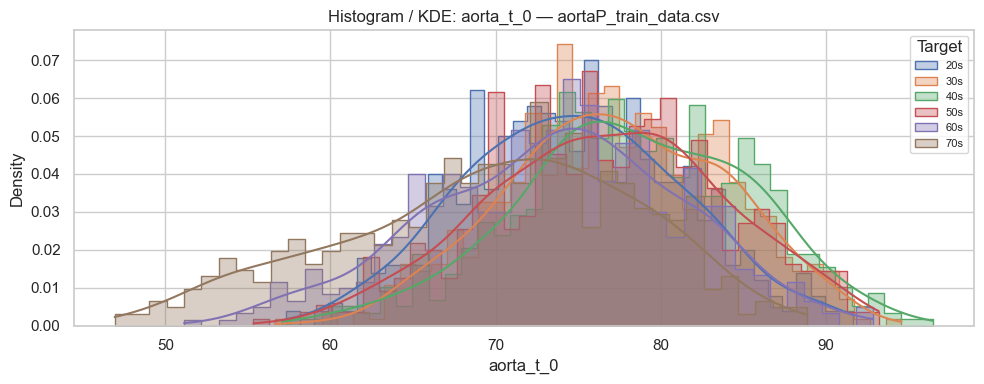

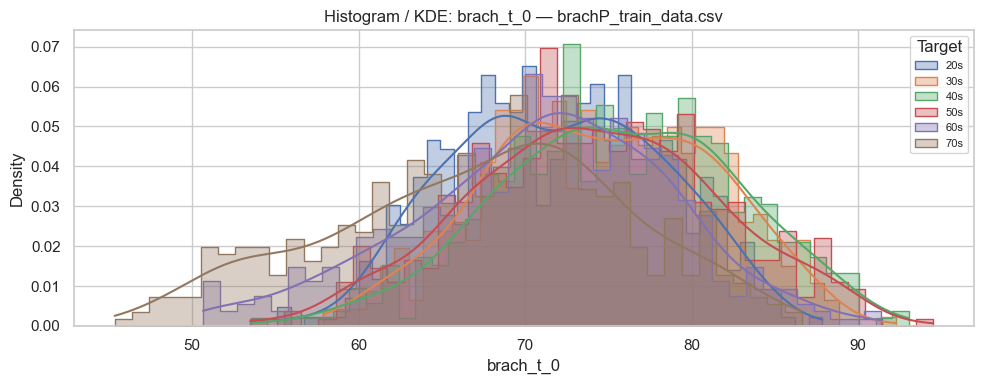

In [13]:
# Run Histogram / KDE for every discovered train CSV

if not train_paths:
    print("No train CSVs found. Run the 'Discover CSV paths and open the UI' cell first.")
else:
    for p in train_paths:
        df = load_train_csv(p)
        cols = numeric_columns(df)
        if not cols:
            print(f"No numeric columns found in {p.name}")
            continue

        col = cols[0]
        fig, ax = plt.subplots(figsize=(10, 4))
        plot_numeric_histogram(ax, df, col, by_target=True, bins=40, kde=True)
        ax.set_title(f"Histogram / KDE: {col} — {p.name}")
        plt.tight_layout()
        plt.show()

### Runner: Violin by target

Runs `plot_violin_or_box(..., kind="violin")` for the first discovered train CSV (requires a `target` column).

In [14]:
# # Run Violin-by-target for every discovered train CSV

# if not train_paths:
#     print("No train CSVs found. Run the 'Discover CSV paths and open the UI' cell first.")
# else:
#     for p in train_paths:
#         df = load_train_csv(p)
#         cols = numeric_columns(df)
#         if "target" not in df.columns:
#             print(f"{p.name} has no 'target' column; violin/box comparisons require target.")
#             continue
#         if not cols:
#             print(f"No numeric columns found in {p.name}")
#             continue

#         col = cols[0]
#         fig, ax = plt.subplots(figsize=(10, 4))
#         plot_violin_or_box(ax, df, col, kind="violin")
#         ax.set_title(f"Violin by target: {col} — {p.name}")
#         plt.tight_layout()
#         plt.show()

### Runner: Box by target

Runs `plot_violin_or_box(..., kind="box")` for the first discovered train CSV (requires a `target` column).

In [15]:
# # Run Box-by-target for every discovered train CSV

# if not train_paths:
#     print("No train CSVs found. Run the 'Discover CSV paths and open the UI' cell first.")
# else:
#     for p in train_paths:
#         df = load_train_csv(p)
#         cols = numeric_columns(df)
#         if "target" not in df.columns:
#             print(f"{p.name} has no 'target' column; violin/box comparisons require target.")
#             continue
#         if not cols:
#             print(f"No numeric columns found in {p.name}")
#             continue

#         col = cols[0]
#         fig, ax = plt.subplots(figsize=(10, 4))
#         plot_violin_or_box(ax, df, col, kind="box")
#         ax.set_title(f"Box by target: {col} — {p.name}")
#         plt.tight_layout()
#         plt.show()

### Runner: Mean waveform (raw mean trace)

Runs `plot_mean_waveforms(...)` for the first discovered train CSV using the first detected waveform prefix.

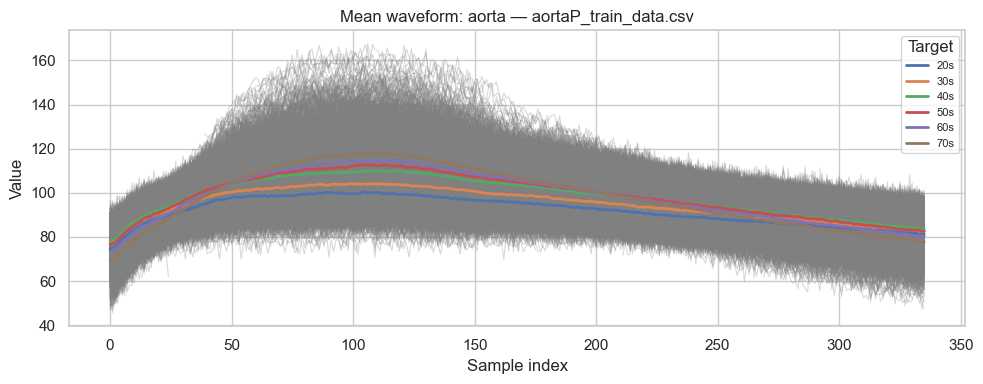

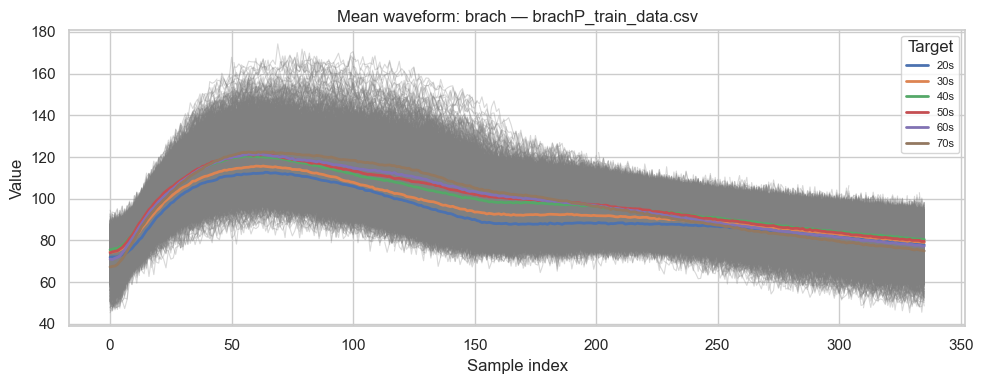

In [16]:
# Run Mean waveform for every discovered train CSV

if not train_paths:
    print("No train CSVs found. Run the 'Discover CSV paths and open the UI' cell first.")
else:
    for p in train_paths:
        df = load_train_csv(p)
        prefixes = list(waveform_time_indices(df.columns).keys())
        if not prefixes:
            print(
                f"No waveform prefixes detected in {p.name} (need columns like {{prefix}}_t_0, {{prefix}}_t_1, ...)"
            )
            continue

        prefix = prefixes[0]
        fig, ax = plt.subplots(figsize=(10, 4))
        plot_mean_waveforms(ax, df, prefix)
        ax.set_title(f"Mean waveform: {prefix} — {p.name}")
        plt.tight_layout()
        plt.show()

### Runner: Subject waveforms (aorta + brach)

Runs `plot_subject_dual_waveforms(...)` for the first discovered **paired** aorta + brach train CSVs (same basename swap as the dashboard), using the **first** overlapping `subject_index`. Toggle `random_subject=True` in the cell for a different subject on each run.

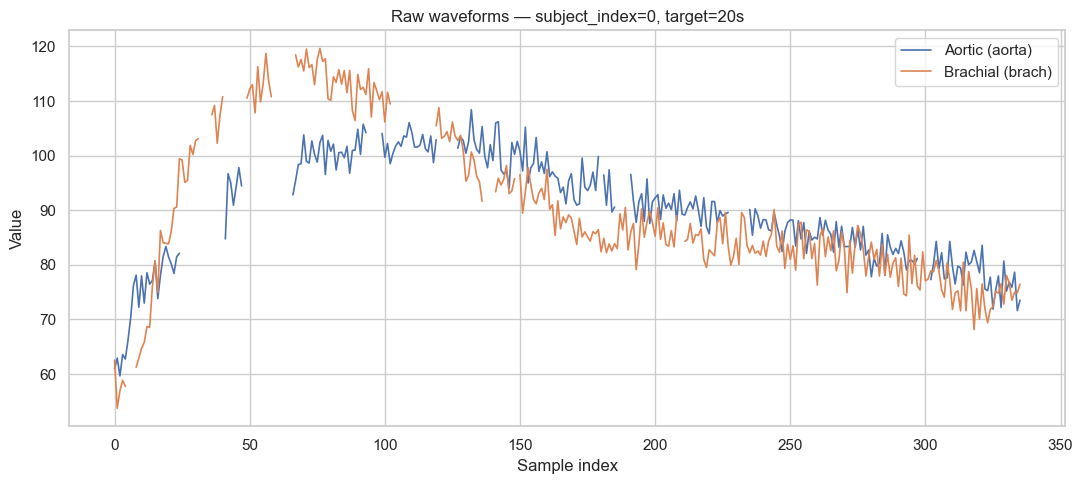

In [17]:
# Run paired aorta + brach raw waveforms (first overlapping subject_index)

if not train_paths:
    print("No train CSVs found. Run the 'Discover CSV paths and open the UI' cell first.")
else:
    root = SEARCH_ROOT.resolve()
    train_paths_rel = [str(p.relative_to(root)) for p in train_paths]
    done = False
    for p in train_paths:
        selected_rel = str(p.relative_to(root))
        aorta_rel, brach_rel = find_companion_waveform_csv(selected_rel, train_paths_rel)
        if not aorta_rel or not brach_rel:
            continue

        df_a = load_train_csv(root / aorta_rel)
        df_b = load_train_csv(root / brach_rel)
        prefs_a = list(waveform_time_indices(df_a.columns).keys())
        prefs_b = list(waveform_time_indices(df_b.columns).keys())
        ap = next((x for x in prefs_a if "aorta" in str(x).lower()), prefs_a[0] if prefs_a else "")
        bp = next((x for x in prefs_b if "brach" in str(x).lower()), prefs_b[0] if prefs_b else "")
        if not ap or not bp:
            print(f"Could not detect aorta/brach waveform prefixes for {aorta_rel} / {brach_rel}")
            continue

        sa = pd.to_numeric(df_a["subject_index"], errors="coerce").dropna().astype(np.int64)
        sb = pd.to_numeric(df_b["subject_index"], errors="coerce").dropna().astype(np.int64)
        common = sorted(set(sa.unique()) & set(sb.unique()))
        if not common:
            print(f"No overlapping subject_index for {aorta_rel} and {brach_rel}")
            continue

        fig, ax = plt.subplots(figsize=(11, 5))
        plot_subject_dual_waveforms(
            ax,
            df_a,
            df_b,
            aorta_prefix=ap,
            brach_prefix=bp,
            subject_index=int(common[0]),
            random_subject=False,
        )
        plt.tight_layout()
        plt.show()
        done = True
        break

    if not done:
        print(
            "No paired aorta + brach train CSVs found (filenames must differ only by aorta/brach), "
            "or pairing failed."
        )

### Runner: Subject waveforms by class (stacked)

Runs `plot_subject_dual_waveforms_by_class_stacked(...)` for the first paired aorta + brach train CSVs. Six **stacked** axes share the sample-index **x-axis**; each row is one decade class (`target` 0–5) with a **random** overlapping subject from that class (re-run the cell for new draws). **Raw** traces use `alpha=0.3`; **Chebyshev-1** filtered traces match in color at full opacity (500 Hz assumed, 25 Hz lowpass default; zero-phase `sosfiltfilt`).

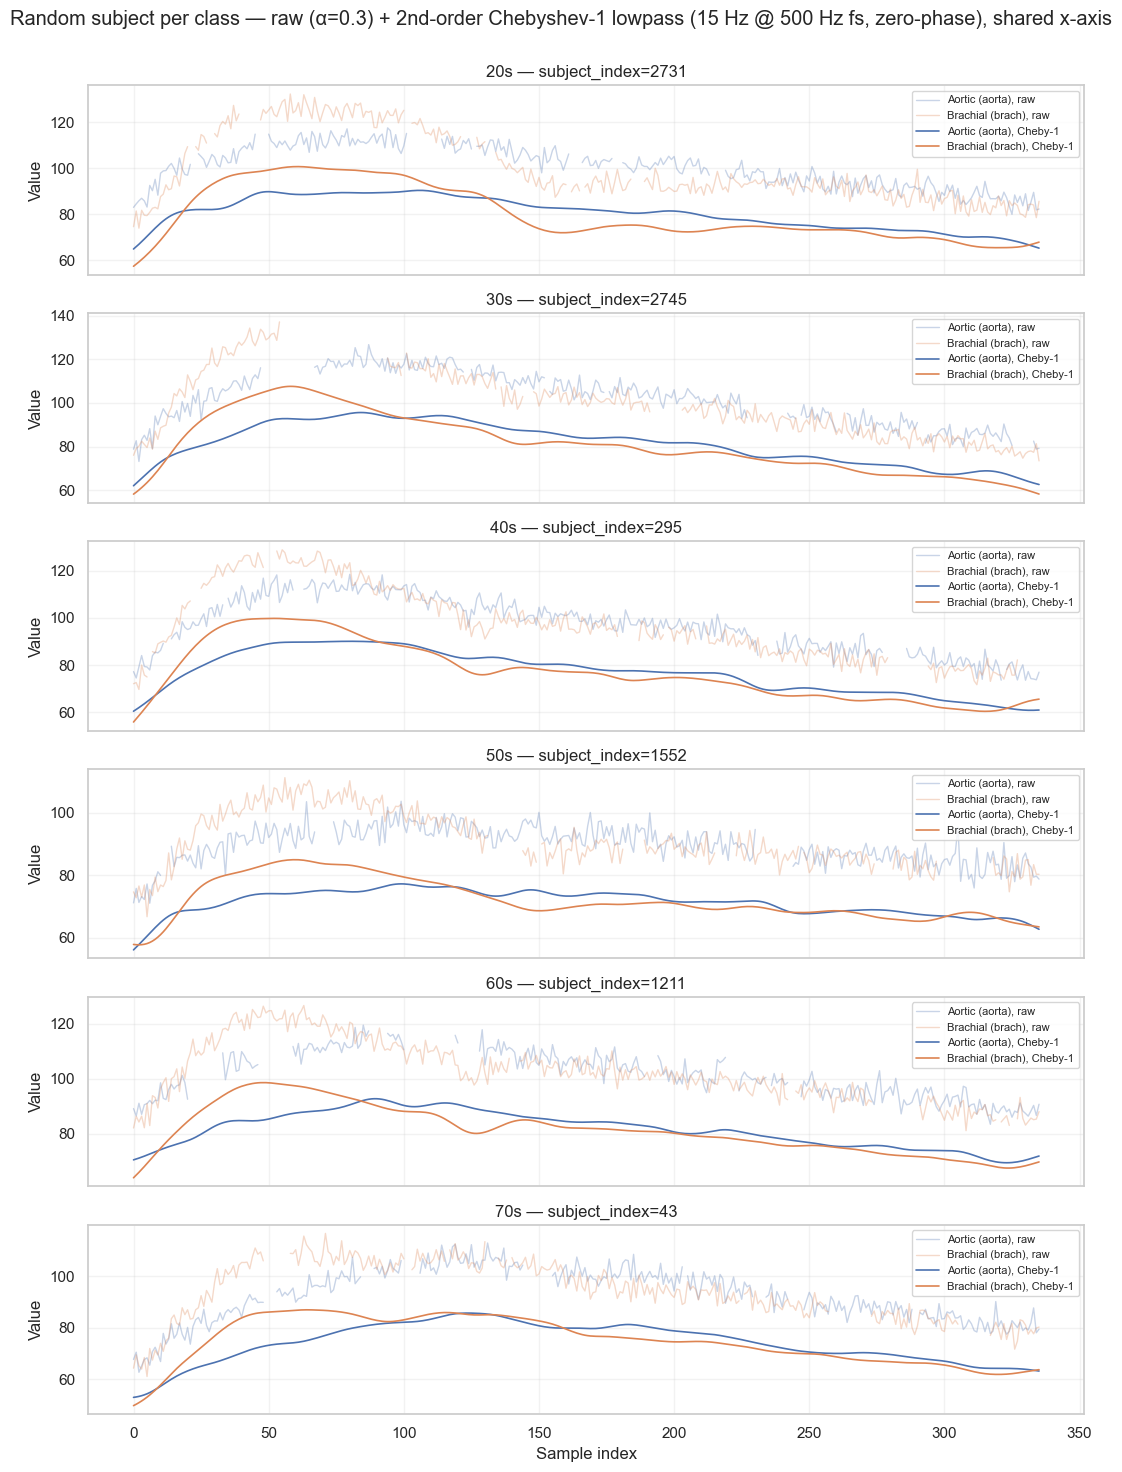

In [18]:
# Stacked random-per-class aorta + brach waveforms (Chebyshev-smoothed, shared x-axis)
# Lowpass cutoff (Hz); must be < Nyquist (default fs = 500 Hz → Nyquist = 250 Hz).
CHEBY_CUTOFF_HZ = 15.0

if not train_paths:
    print("No train CSVs found. Run the 'Discover CSV paths and open the UI' cell first.")
else:
    root = SEARCH_ROOT.resolve()
    train_paths_rel = [str(p.relative_to(root)) for p in train_paths]
    done = False
    for p in train_paths:
        selected_rel = str(p.relative_to(root))
        aorta_rel, brach_rel = find_companion_waveform_csv(selected_rel, train_paths_rel)
        if not aorta_rel or not brach_rel:
            continue

        df_a = load_train_csv(root / aorta_rel)
        df_b = load_train_csv(root / brach_rel)
        prefs_a = list(waveform_time_indices(df_a.columns).keys())
        prefs_b = list(waveform_time_indices(df_b.columns).keys())
        ap = next((x for x in prefs_a if "aorta" in str(x).lower()), prefs_a[0] if prefs_a else "")
        bp = next((x for x in prefs_b if "brach" in str(x).lower()), prefs_b[0] if prefs_b else "")
        if not ap or not bp:
            print(f"Could not detect aorta/brach waveform prefixes for {aorta_rel} / {brach_rel}")
            continue

        plot_subject_dual_waveforms_by_class_stacked(
            df_a,
            df_b,
            aorta_prefix=ap,
            brach_prefix=bp,
            cheby_cutoff_hz=CHEBY_CUTOFF_HZ,
        )
        plt.show()
        done = True
        break

    if not done:
        print(
            "No paired aorta + brach train CSVs found (filenames must differ only by aorta/brach), "
            "or pairing failed."
        )

### Runner: Missingness

Runs `plot_missingness(...)` for the first discovered train CSV (top N columns by missing rate).

In [19]:
# # Run Missingness plot for every discovered train CSV

# if not train_paths:
#     print("No train CSVs found. Run the 'Discover CSV paths and open the UI' cell first.")
# else:
#     for p in train_paths:
#         df = load_train_csv(p)
#         fig, ax = plt.subplots(figsize=(10, 6))
#         plot_missingness(ax, df, max_cols=30)
#         ax.set_title(f"Missingness — {p.name}")
#         plt.tight_layout()
#         plt.show()

### Runner: Correlation sample

Runs `plot_correlation_sample(...)` for the first discovered train CSV on a sampled set of numeric waveform columns (and includes `target` when present).

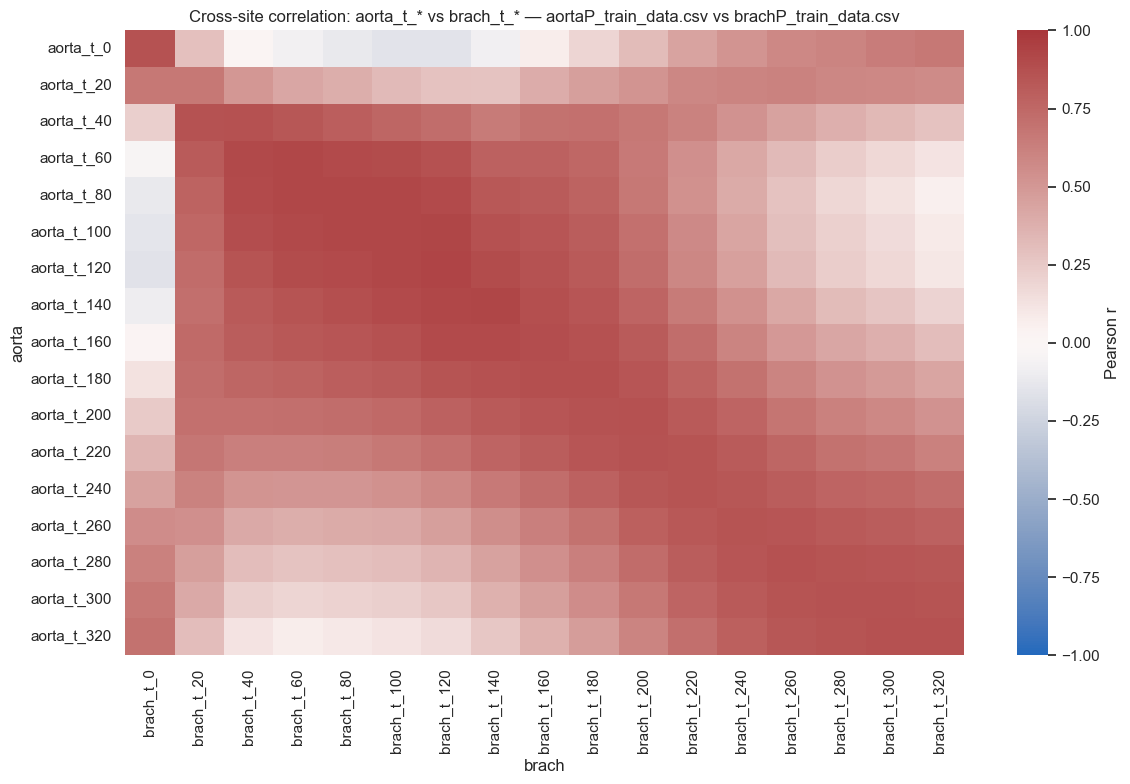

In [20]:
# Run a single *cross-site* correlation heatmap: aorta_t_* vs brach_t_*


def _pick_first_matching(paths: list[Path], *needles: str) -> Path | None:
    needles_l = [n.lower() for n in needles]
    for p in paths:
        s = str(p).lower()
        if all(n in s for n in needles_l):
            return p
    return None


# Prefer discovered paths (train_paths) but fall back to known local dataset paths.
search_pool: list[Path] = []
if "train_paths" in globals() and train_paths:
    search_pool = list(train_paths)

p_aorta = _pick_first_matching(search_pool, "aorta", "train")
p_brach = _pick_first_matching(search_pool, "brach", "train")

if p_aorta is None:
    cand = Path("datasets/train/aortaP_train_data.csv")
    p_aorta = cand if cand.exists() else None
if p_brach is None:
    cand = Path("datasets/train/brachP_train_data.csv")
    p_brach = cand if cand.exists() else None

if p_aorta is None or p_brach is None:
    print("Could not locate both aorta + brachial train CSVs.")
else:
    df_a = load_train_csv(p_aorta)
    df_b = load_train_csv(p_brach)

    # Align rows (subject_index preferred)
    if "subject_index" in df_a.columns:
        df_a = df_a.set_index("subject_index", drop=False)
    if "subject_index" in df_b.columns:
        df_b = df_b.set_index("subject_index", drop=False)

    joined = df_a.join(df_b, how="inner", lsuffix="_aorta", rsuffix="_brach")

    # Sample waveform-like columns from both sites.
    a_cols = [c for c in joined.columns if re.search(r"^aorta_t_\d+$", str(c))]
    b_cols = [c for c in joined.columns if re.search(r"^brach_t_\d+$", str(c))]
    a_cols = sorted(a_cols, key=lambda s: int(str(s).rsplit("_t_", 1)[-1]))
    b_cols = sorted(b_cols, key=lambda s: int(str(s).rsplit("_t_", 1)[-1]))

    step = 20
    a_sample = a_cols[::step][:25]
    b_sample = b_cols[::step][:25]

    if not a_sample or not b_sample:
        print("Missing aorta_t_* or brach_t_* columns; cannot compute cross-site correlations.")
    else:
        # Rectangular correlation matrix: corr(aorta_i, brach_j)
        corr = pd.DataFrame(index=a_sample, columns=b_sample, dtype=float)
        for ac in a_sample:
            a = pd.to_numeric(joined[ac], errors="coerce")
            for bc in b_sample:
                b = pd.to_numeric(joined[bc], errors="coerce")
                corr.loc[ac, bc] = a.corr(b)

        fig, ax = plt.subplots(figsize=(12, 8))
        sns.heatmap(
            corr,
            ax=ax,
            vmin=-1,
            vmax=1,
            center=0,
            cmap="vlag",
            cbar_kws={"label": "Pearson r"},
        )
        ax.set_title(f"Cross-site correlation: aorta_t_* vs brach_t_* — {p_aorta.name} vs {p_brach.name}")
        ax.set_xlabel("brach")
        ax.set_ylabel("aorta")
        plt.tight_layout()
        plt.show()

### Runner: Aorta vs brachial (PPA + systolic spread)

In [21]:
# # Run paired aorta vs brachial metrics (PPA + systolic spread)


# def _pick_first_matching(paths: list[Path], *needles: str) -> Path | None:
#     needles_l = [n.lower() for n in needles]
#     for p in paths:
#         s = str(p).lower()
#         if all(n in s for n in needles_l):
#             return p
#     return None


# # Prefer discovered paths (train_paths) but fall back to known local dataset paths.
# search_pool: list[Path] = []
# if "train_paths" in globals() and train_paths:
#     search_pool = list(train_paths)

# p_aorta = _pick_first_matching(search_pool, "aorta", "train")
# p_brach = _pick_first_matching(search_pool, "brach", "train")

# if p_aorta is None:
#     cand = Path("datasets/train/aortaP_train_data.csv")
#     p_aorta = cand if cand.exists() else None
# if p_brach is None:
#     cand = Path("datasets/train/brachP_train_data.csv")
#     p_brach = cand if cand.exists() else None

# if p_aorta is None or p_brach is None:
#     print("Could not locate both aorta + brachial train CSVs.")
#     print("Expected one file matching 'aorta' and one matching 'brach' in train_paths or under datasets/train/.")
# else:
#     print(f"Using aorta:  {p_aorta}")
#     print(f"Using brach:  {p_brach}")

#     df_a = load_train_csv(p_aorta)
#     df_b = load_train_csv(p_brach)

#     paired = compute_aorta_brachial_metrics(df_a, df_b, aorta_prefix="aorta", brach_prefix="brach")
#     plot_ppa_and_systolic_spread(paired, title=f"PPA + systolic spread — {p_aorta.name} vs {p_brach.name}")

### Runner: Aorta vs brachial temporal features (ARV/CV/Slope)

In [22]:
# # Run aorta vs brachial temporal features (ARV/CV/Slope)


# def _pick_first_matching(paths: list[Path], *needles: str) -> Path | None:
#     needles_l = [n.lower() for n in needles]
#     for p in paths:
#         s = str(p).lower()
#         if all(n in s for n in needles_l):
#             return p
#     return None


# window = 10  # rolling window size for temporal features

# # Prefer discovered paths (train_paths) but fall back to known local dataset paths.
# search_pool: list[Path] = []
# if "train_paths" in globals() and train_paths:
#     search_pool = list(train_paths)

# p_aorta = _pick_first_matching(search_pool, "aorta", "train")
# p_brach = _pick_first_matching(search_pool, "brach", "train")

# if p_aorta is None:
#     cand = Path("datasets/train/aortaP_train_data.csv")
#     p_aorta = cand if cand.exists() else None
# if p_brach is None:
#     cand = Path("datasets/train/brachP_train_data.csv")
#     p_brach = cand if cand.exists() else None

# if p_aorta is None or p_brach is None:
#     print("Could not locate both aorta + brachial train CSVs.")
#     print("Expected one file matching 'aorta' and one matching 'brach' in train_paths or under datasets/train/.")
# else:
#     print(f"Using aorta:  {p_aorta}")
#     print(f"Using brach:  {p_brach}")

#     df_a = load_train_csv(p_aorta)
#     df_b = load_train_csv(p_brach)

#     feats = compute_aorta_brachial_temporal_features(
#         df_a,
#         df_b,
#         aorta_prefix="aorta",
#         brach_prefix="brach",
#         window=window,
#     )

#     plot_temporal_feature_distributions(
#         feats,
#         window=window,
#         title=f"Temporal features (window={window}) — {p_aorta.name} vs {p_brach.name}",
#     )

### Runner: Feature correlation matrix (PPA + PP peak + temporal features)

In [23]:
# # Correlation matrix across extracted features


# def _pick_first_matching(paths: list[Path], *needles: str) -> Path | None:
#     needles_l = [n.lower() for n in needles]
#     for p in paths:
#         s = str(p).lower()
#         if all(n in s for n in needles_l):
#             return p
#     return None


# # Prefer discovered paths (train_paths) but fall back to known local dataset paths.
# search_pool: list[Path] = []
# if "train_paths" in globals() and train_paths:
#     search_pool = list(train_paths)

# p_aorta = _pick_first_matching(search_pool, "aorta", "train")
# p_brach = _pick_first_matching(search_pool, "brach", "train")

# if p_aorta is None:
#     cand = Path("datasets/train/aortaP_train_data.csv")
#     p_aorta = cand if cand.exists() else None
# if p_brach is None:
#     cand = Path("datasets/train/brachP_train_data.csv")
#     p_brach = cand if cand.exists() else None

# window = 10

# if p_aorta is None or p_brach is None:
#     print("Could not locate both aorta + brachial train CSVs.")
# else:
#     df_a = load_train_csv(p_aorta)
#     df_b = load_train_csv(p_brach)

#     paired = compute_aorta_brachial_metrics(df_a, df_b, aorta_prefix="aorta", brach_prefix="brach")
#     temporal = compute_aorta_brachial_temporal_features(
#         df_a,
#         df_b,
#         aorta_prefix="aorta",
#         brach_prefix="brach",
#         window=window,
#     )

#     feat = paired.metrics.join(temporal, how="inner", rsuffix="_tmp")

#     feature_cols = [
#         # PPA
#         "ppa_ratio",
#         "ppa_diff",
#         # PP peak (per site)
#         "aorta_pp",
#         "brach_pp",
#         # Rolling-window temporal features
#         "aorta_arv_roll_mean",
#         "brach_arv_roll_mean",
#         "aorta_cv_roll_mean",
#         "brach_cv_roll_mean",
#         "aorta_slope_roll_mean",
#         "brach_slope_roll_mean",
#     ]

#     X = feat[[c for c in feature_cols if c in feat.columns]].apply(pd.to_numeric, errors="coerce")
#     X = X.dropna(axis=0, how="any")

#     if X.shape[1] < 2:
#         print("Not enough feature columns to compute a correlation matrix.")
#     else:
#         corr = X.corr()
#         fig, ax = plt.subplots(figsize=(11, 9))
#         sns.heatmap(corr, ax=ax, vmin=-1, vmax=1, center=0, cmap="vlag", annot=True, fmt=".2f")
#         ax.set_title(
#             f"Feature correlation matrix (window={window})\n{p_aorta.name} vs {p_brach.name}"
#         )
#         plt.tight_layout()
#         plt.show()

#         # Keep for the covariance / pairplot cells below
#         _FEATURE_TABLE = X

#         _FEATURE_PAIR = X.copy()
#         if "target" in feat.columns:
#             _FEATURE_PAIR["target"] = pd.to_numeric(feat.loc[X.index, "target"], errors="coerce")

### Runner: Feature covariance matrix (same extracted features)

In [24]:
# # Covariance matrix across extracted features

# if "_FEATURE_TABLE" not in globals():
#     print("Run the 'Feature correlation matrix' cell first (it builds _FEATURE_TABLE).")
# else:
#     df = _FEATURE_TABLE.copy()
#     num = df.select_dtypes("number")

#     # If you *expect* diagonal entries == 1.0, that's correlation (or covariance of z-scored features),
#     # not raw covariance. Toggle this on to z-score first.
#     standardize = False

#     if num.shape[1] < 2:
#         print("Not enough numeric feature columns to compute a covariance matrix.")
#     else:
#         if standardize:
#             z = (num - num.mean()) / num.std(ddof=1)
#             mat = z.cov()
#             title = "Standardized covariance (== correlation; diagonal=1)"
#             cbar = "Covariance (z-scored)"
#         else:
#             mat = num.cov()
#             title = "Feature covariance matrix (diagonal is variance)"
#             cbar = "Covariance"

#         vmax = float(np.nanmax(np.abs(mat.to_numpy())))

#         fig, ax = plt.subplots(figsize=(11, 9))
#         sns.heatmap(
#             mat,
#             ax=ax,
#             cmap="vlag",
#             center=0,
#             vmin=-vmax,
#             vmax=vmax,
#             annot=True,
#             fmt=".3g",
#             cbar_kws={"label": cbar},
#             square=True,
#         )
#         ax.set_title(title)
#         plt.tight_layout()
#         plt.show()

### Runner: Pairplot of extracted features

In [25]:
# # Pairplot of extracted features

# if "_FEATURE_TABLE" not in globals():
#     print("Run the 'Feature correlation matrix' cell first (it builds _FEATURE_TABLE).")
# else:
#     df = _FEATURE_TABLE.copy().select_dtypes("number")
#     if df.shape[1] < 2:
#         print("Not enough numeric feature columns to pairplot.")
#     else:
#         sns.pairplot(df, corner=True, plot_kws={"alpha": 0.4, "s": 12})

### Runner: Pairplot by target class

In [26]:
# # Pairplot of extracted features, colored by target class

# if "_FEATURE_PAIR" not in globals():
#     print("Run the 'Feature correlation matrix' cell first (it builds _FEATURE_PAIR).")
# else:
#     plot_df = _FEATURE_PAIR.dropna()
#     num_cols = [c for c in plot_df.columns if c != "target"]
#     if len(num_cols) < 2:
#         print("Not enough numeric feature columns for a pairplot.")
#     elif "target" in plot_df.columns and plot_df["target"].notna().any():
#         sns.pairplot(
#             plot_df,
#             vars=num_cols,
#             hue="target",
#             corner=True,
#             plot_kws={"alpha": 0.35, "s": 14},
#             diag_kind="hist",
#         )
#     else:
#         sns.pairplot(
#             plot_df[num_cols],
#             corner=True,
#             plot_kws={"alpha": 0.35, "s": 14},
#         )

## Run Full UI

In [27]:
# Launch the interactive dashboard
#
# This assumes you've run the imports/setup + plotting helper cells above,
# and that `train_paths` has been populated by the discovery cell.

# if not train_paths:
#     print("No train CSVs found. Run the discovery cell first (or adjust SEARCH_ROOT / FILENAME_SUBSTRING).")
# else:
#     build_ui(train_paths)

## Arterial waveform landmarks (optional)

[`arterial_waveform_features.py`](arterial_waveform_features.py) implements systolic/diastolic detection (`scipy.signal.find_peaks`, inverted trace for the foot), dicrotic notch via $dP/dt$, systolic/diastolic **AUC** split at the notch, **form factor**, **$dP/dt_{max}$**, crest time, and **foot-to-foot PTT** when a brachial trace is supplied (500 Hz → **2 ms/sample**). **NaN gaps** in the train CSV waveforms are linearly interpolated before detection (same idea as `heart_age_classifier`), so landmarks and the feature text box populate reliably.

Run the next cell after the path helpers exist (`SEARCH_ROOT`, `load_train_csv`, `find_companion_waveform_csv`, `waveform_columns_for_prefix`).

--- class 0 (20s) subject_index=1611 ---
  beat 0: BeatFeatures(idx_foot=0, idx_peak=70, idx_notch=174, idx_beat_end=335, p_sys=94.87399522262527, p_dia=60.554415204260735, pulse_pressure=34.31958001836453, p_notch=81.29372445989681, auc_sys=30.071764260724972, auc_dia=23.608487298755993, auc_ratio_sys_over_dia=1.2737692119015838, t_crest_ms=140.0, dp_dt_max=436.88031769576696, form_factor=0.5686584182751211)
  PTT_ms: 0.0
--- class 1 (30s) subject_index=2259 ---
  beat 0: BeatFeatures(idx_foot=0, idx_peak=103, idx_notch=169, idx_beat_end=335, p_sys=88.66636389684447, p_dia=63.44738576240311, pulse_pressure=25.218978134441365, p_notch=84.69937657110069, auc_sys=28.32893203067407, auc_dia=26.100237818517098, auc_ratio_sys_over_dia=1.0853898047846828, t_crest_ms=206.0, dp_dt_max=277.04738181251184, form_factor=0.7039391404062605)
  PTT_ms: 0.0
--- class 2 (40s) subject_index=1429 ---
  beat 0: BeatFeatures(idx_foot=0, idx_peak=61, idx_notch=177, idx_beat_end=335, p_sys=77.22804873970078,

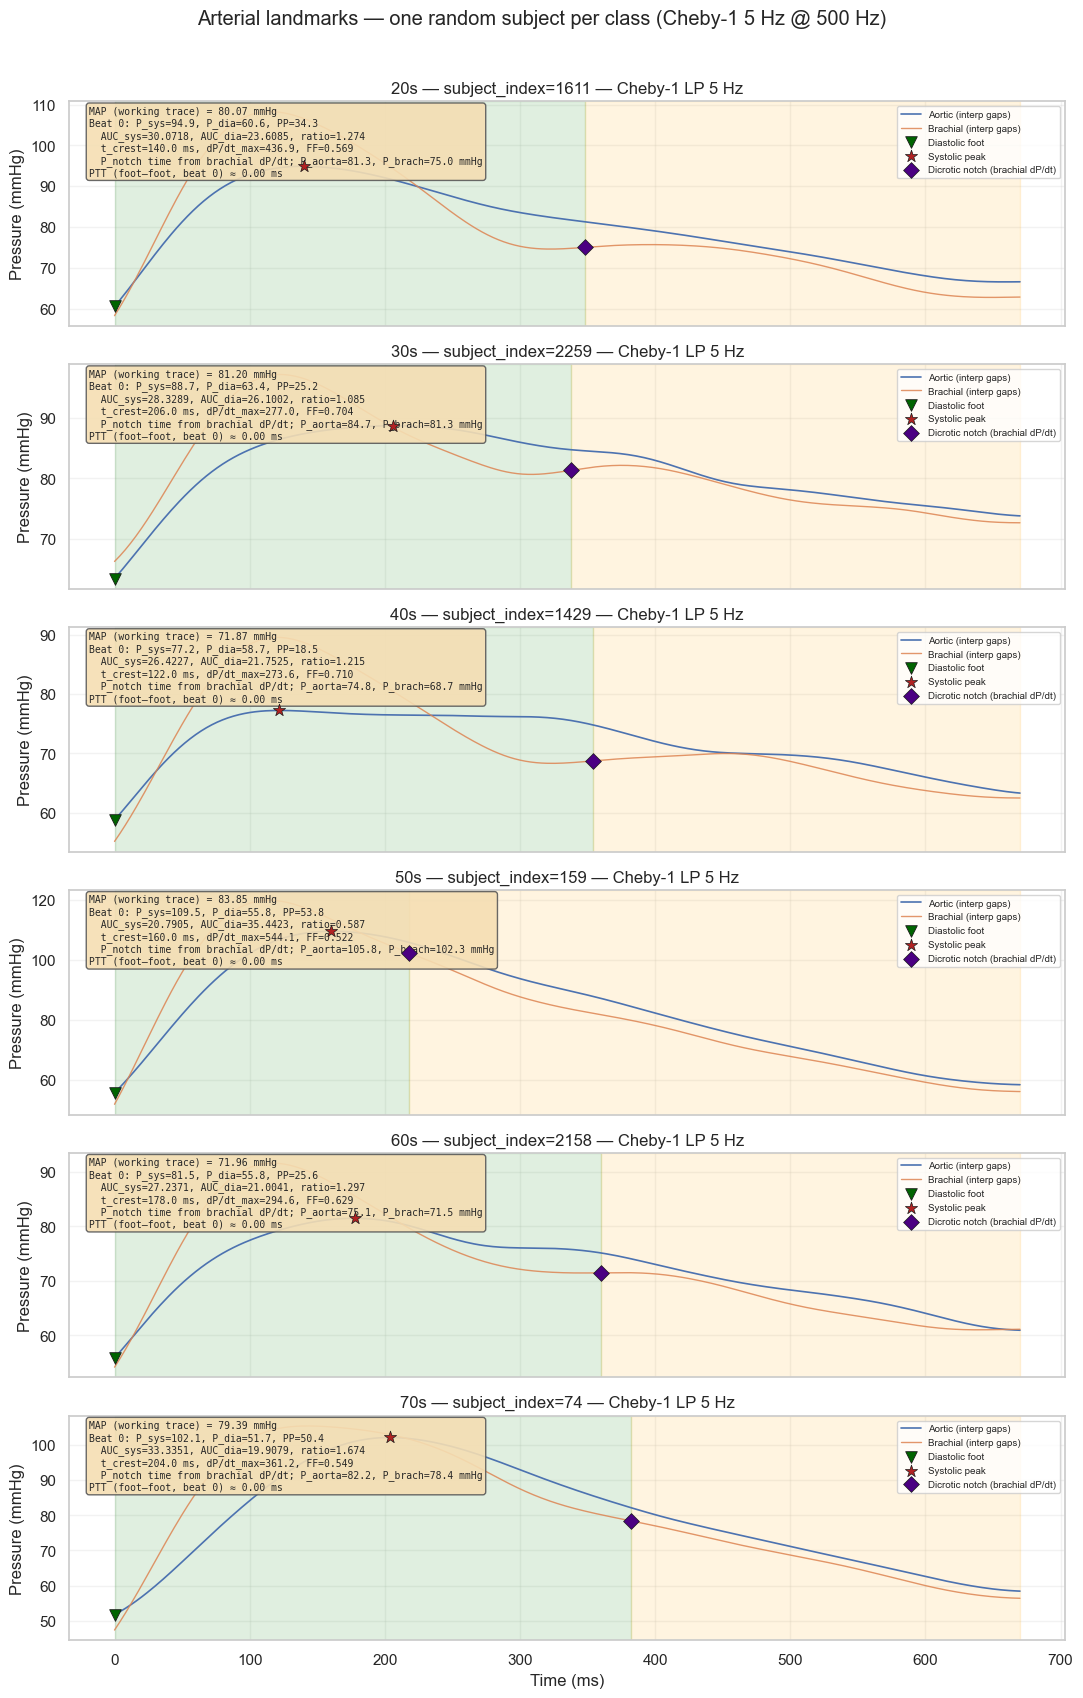

In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from arterial_waveform_features import analyze_pressure_waveform, display_arterial_waveform_analysis


def run_arterial_feature_display(
    subject_index: int | None = None,
    *,
    per_class_random_seed: int | None = None,
    sample_rate_hz: float = 500.0,
    prominence_mmhg: float = 10.0,
    min_peak_distance_samples: int = 200,
    cheby_cutoff_hz: float | None = None,
    cheby_rp: float = 1.0,
    assume_first_sample_is_foot: bool = False,
    assume_one_beat_per_trace: bool = False,
    dicrotic_notch_source: str = "aorta",
    aorta_prefix: str = "aorta",
    brach_prefix: str = "brach",
    title_suffix: str = "",
) -> None:
    """Load paired aorta/brach train CSVs; arterial landmarks on one subject or one per class.

    - Single subject: set ``subject_index`` (or leave ``None`` for the first row) and
      leave ``per_class_random_seed=None``.
    - One **random** overlapping subject per ``target`` class (0–5): set
      ``per_class_random_seed`` to an integer (same seed ⇒ same draws, as in
      ``plot_subject_dual_waveforms_by_class_stacked``). ``subject_index`` is then ignored.

    When ``cheby_cutoff_hz`` is not None, apply ``smooth_waveform_cheby1_order2`` before analysis.

    When ``assume_first_sample_is_foot`` is True, beat 0 uses index 0 as the diastolic foot.

    When ``assume_one_beat_per_trace`` is True, only the first systolic peak is used (one beat per row).

    Set ``dicrotic_notch_source='brachial'`` to place the notch (and aortic AUC split time) using the brachial dP/dt when the notch is clearer there.
    """
    if not train_paths:
        raise RuntimeError("Run the Discover cell first so `train_paths` is non-empty.")

    train_paths_rel = [str(p.relative_to(SEARCH_ROOT)) for p in train_paths]
    aorta_rel, brach_rel = None, None
    for r in train_paths_rel:
        if "aorta" in Path(r).name.lower():
            aorta_rel, brach_rel = find_companion_waveform_csv(r, train_paths_rel)
            if aorta_rel and brach_rel:
                break

    if not aorta_rel or not brach_rel:
        print("Could not resolve paired aorta + brach CSVs under SEARCH_ROOT.")
        return

    df_a = load_train_csv(SEARCH_ROOT / aorta_rel)
    df_b = load_train_csv(SEARCH_ROOT / brach_rel)
    ca = waveform_columns_for_prefix(df_a, aorta_prefix)
    cb = waveform_columns_for_prefix(df_b, brach_prefix)
    if not ca or not cb:
        print(f"Missing waveform columns for prefixes {aorta_prefix!r} / {brach_prefix!r}")
        return

    if per_class_random_seed is not None:
        rng = np.random.default_rng(per_class_random_seed)
        class_ids = sorted(TARGET_LABELS.keys())
        n_cls = len(class_ids)

        if "target" not in df_a.columns:
            print("Need `target` on aorta CSV for per-class sampling.")
            return

        sa = pd.to_numeric(df_a["subject_index"], errors="coerce").dropna().astype(np.int64)
        sb = pd.to_numeric(df_b["subject_index"], errors="coerce").dropna().astype(np.int64)
        common = sorted(set(sa.unique()) & set(sb.unique()))
        if not common:
            print("No overlapping subject_index between aorta and brach CSVs.")
            return

        sub = df_a[df_a["subject_index"].isin(common)][["subject_index", "target"]].copy()
        sub["target"] = pd.to_numeric(sub["target"], errors="coerce")
        sub = sub.dropna(subset=["target"])
        sub["target"] = sub["target"].astype(int)

        fig, axes = plt.subplots(n_cls, 1, figsize=(11, 2.8 * n_cls), sharex=True)
        if n_cls == 1:
            axes = np.array([axes])

        for ax_i, t in zip(axes, class_ids):
            pool = sub.loc[sub["target"] == t, "subject_index"].astype(int).unique().tolist()
            if not pool:
                ax_i.text(
                    0.5,
                    0.5,
                    f"No subjects with target={t} ({TARGET_LABELS.get(t, '')})",
                    ha="center",
                    va="center",
                    transform=ax_i.transAxes,
                )
                ax_i.set_axis_off()
                continue

            sid = int(rng.choice(pool))
            row_a = df_a.loc[df_a["subject_index"] == sid].iloc[0]
            row_b = df_b.loc[df_b["subject_index"] == sid].iloc[0]
            ya = pd.to_numeric(row_a[ca], errors="coerce").to_numpy(dtype=float)
            yb = pd.to_numeric(row_b[cb], errors="coerce").to_numpy(dtype=float)
            n = min(ya.size, yb.size)
            ya, yb = ya[:n], yb[:n]

            if cheby_cutoff_hz is not None:
                ya = smooth_waveform_cheby1_order2(
                    ya,
                    sample_rate_hz=sample_rate_hz,
                    cutoff_hz=cheby_cutoff_hz,
                    rp=cheby_rp,
                )
                yb = smooth_waveform_cheby1_order2(
                    yb,
                    sample_rate_hz=sample_rate_hz,
                    cutoff_hz=cheby_cutoff_hz,
                    rp=cheby_rp,
                )

            res = analyze_pressure_waveform(
                ya,
                sample_rate_hz=sample_rate_hz,
                prominence_mmhg=prominence_mmhg,
                min_peak_distance_samples=min_peak_distance_samples,
                brachial_pressure=yb,
                assume_first_sample_is_foot=assume_first_sample_is_foot,
                assume_one_beat_per_trace=assume_one_beat_per_trace,
                dicrotic_notch_source=dicrotic_notch_source,
            )
            lbl = TARGET_LABELS.get(t, str(t))
            print(f"--- class {t} ({lbl}) subject_index={sid} ---")
            for i, b in enumerate(res.beats):
                print(f"  beat {i}:", b)
            print("  PTT_ms:", res.ptt_ms)

            row_title = f"{lbl} — subject_index={sid}"
            if cheby_cutoff_hz is not None:
                row_title = f"{row_title} — Cheby-1 LP {cheby_cutoff_hz:g} Hz"
            if title_suffix:
                row_title = f"{row_title} ({title_suffix})"

            display_arterial_waveform_analysis(
                ya,
                yb,
                sample_rate_hz=sample_rate_hz,
                prominence_mmhg=prominence_mmhg,
                min_peak_distance_samples=min_peak_distance_samples,
                assume_first_sample_is_foot=assume_first_sample_is_foot,
                assume_one_beat_per_trace=assume_one_beat_per_trace,
                dicrotic_notch_source=dicrotic_notch_source,
                title=row_title,
                ax=ax_i,
                result=res,
                show=False,
                show_xlabel=(t == class_ids[-1]),
                annotation_fontsize=7.0,
                legend_fontsize=7.0,
            )

        supt = "Arterial landmarks — one random subject per class"
        if cheby_cutoff_hz is not None:
            supt = f"{supt} (Cheby-1 {cheby_cutoff_hz:g} Hz @ {sample_rate_hz:g} Hz)"
        if title_suffix:
            supt = f"{supt} ({title_suffix})"
        fig.suptitle(supt, y=1.01)
        fig.tight_layout()
        plt.show()
        return

    # --- single-subject mode ---
    if subject_index is None:
        subject_index = int(df_a["subject_index"].iloc[0])

    ra = df_a.loc[df_a["subject_index"] == subject_index]
    rb = df_b.loc[df_b["subject_index"] == subject_index]
    if ra.empty or rb.empty:
        print(f"No row for subject_index={subject_index}")
        return

    ya = ra.iloc[0][ca].to_numpy(dtype=float)
    yb = rb.iloc[0][cb].to_numpy(dtype=float)
    n = min(ya.size, yb.size)
    ya, yb = ya[:n], yb[:n]

    if cheby_cutoff_hz is not None:
        ya = smooth_waveform_cheby1_order2(
            ya,
            sample_rate_hz=sample_rate_hz,
            cutoff_hz=cheby_cutoff_hz,
            rp=cheby_rp,
        )
        yb = smooth_waveform_cheby1_order2(
            yb,
            sample_rate_hz=sample_rate_hz,
            cutoff_hz=cheby_cutoff_hz,
            rp=cheby_rp,
        )

    res = analyze_pressure_waveform(
        ya,
        sample_rate_hz=sample_rate_hz,
        prominence_mmhg=prominence_mmhg,
        min_peak_distance_samples=min_peak_distance_samples,
        brachial_pressure=yb,
        assume_first_sample_is_foot=assume_first_sample_is_foot,
        assume_one_beat_per_trace=assume_one_beat_per_trace,
        dicrotic_notch_source=dicrotic_notch_source,
    )
    for i, b in enumerate(res.beats):
        print(f"beat {i}:", b)
    print("PTT_ms:", res.ptt_ms)

    title = f"Arterial features — subject {subject_index}"
    if cheby_cutoff_hz is not None:
        title = f"{title} — Cheby-1 LP {cheby_cutoff_hz:g} Hz @ {sample_rate_hz:g} Hz"
    if title_suffix:
        title = f"{title} ({title_suffix})"

    display_arterial_waveform_analysis(
        ya,
        yb,
        sample_rate_hz=sample_rate_hz,
        prominence_mmhg=prominence_mmhg,
        min_peak_distance_samples=min_peak_distance_samples,
        assume_first_sample_is_foot=assume_first_sample_is_foot,
        assume_one_beat_per_trace=assume_one_beat_per_trace,
        dicrotic_notch_source=dicrotic_notch_source,
        title=title,
    )


# Example: reproducible random subject per decade (same seed ⇒ same subjects)
run_arterial_feature_display(
    per_class_random_seed=43,
    dicrotic_notch_source="brachial",  # "aorta" or "brachial"
    prominence_mmhg=10,
    min_peak_distance_samples=200,
    cheby_cutoff_hz=5,
    assume_first_sample_is_foot=True,
    assume_one_beat_per_trace=True,
)
